# KDRT tanpa link


## Install dan import library

In [ ]:
!pip install wordcloud

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 12.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os

In [ ]:
df_kdrt = pd.read_csv('Dataset KDRT 8rb Cleaning.csv',delimiter=';', encoding='ISO-8859-1')

In [ ]:
df_kdrt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4290 entries, 0 to 4289
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   username    4288 non-null   object 
 1   full_text   4290 non-null   object 
 2   sentimen    3075 non-null   object 
 3   Unnamed: 3  0 non-null      float64
 4   Unnamed: 4  1 non-null      object 
dtypes: float64(1), object(4)
memory usage: 167.7+ KB


In [ ]:
df_kdrt.drop(columns=['Unnamed: 3','Unnamed: 4'], inplace=True)

In [ ]:
df_kdrt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4290 entries, 0 to 4289
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   username   4288 non-null   object
 1   full_text  4290 non-null   object
 2   sentimen   3075 non-null   object
dtypes: object(3)
memory usage: 100.7+ KB


In [ ]:
df_kdrt.head()

,username,full_text,sentimen
0,ruangtahul,Menikah adalah hal yang baik. Konsekuensinya a...,positif
1,XANOSHITA,@SitiMelyanaaa pelaku kdrt ini keknya bisa dip...,positif
2,ShinFa_04,@ngemtot @iamoneofwan Solusi tolol! Pantesan l...,negatif
3,ShinFa_04,@ngemtot Sewajarnya itu ambigu loh bocil norma...,negatif
4,imajinasihujan,Kenapa sekarang banyak wanita independen? Kare...,negatif


In [ ]:
df_kdrt.isna().sum()

,0
username,2
full_text,0
sentimen,1215


In [ ]:
df_kdrt["sentimen"].value_counts()

,count
sentimen,
negatif,2515
positif,560


# BAGI 2 df_nolink dan df_withlink :
1. Baris yang ada link dihapus
2. Hanya hapus linknya namun barisnya tidak dihapus

In [ ]:
df_withLink = df_kdrt.copy()

In [ ]:
df_withLink['full_text'] = df_withLink['full_text'].str.replace(
    r'http\S+|www\S+|https\S+', '', regex=True
)

In [ ]:
df_withLink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4290 entries, 0 to 4289
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   username   4288 non-null   object
 1   full_text  4290 non-null   object
 2   sentimen   3075 non-null   object
dtypes: object(3)
memory usage: 100.7+ KB


In [ ]:
df_withLink.to_csv('dataset kdrt 4k withLink_uncleaned.csv', index=False)

## Hapus tweet yang terdapat link

In [ ]:
# Remove rows with URLs in 'full_text'
df_noLink = df_kdrt[~df_kdrt['full_text'].str.contains(r'http\S+|www\S+|https\S+', na=False)]

In [ ]:
# Display the updated DataFrame info
df_noLink.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3630 entries, 0 to 4287
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   username   3628 non-null   object
 1   full_text  3630 non-null   object
 2   sentimen   2876 non-null   object
dtypes: object(3)
memory usage: 113.4+ KB


In [ ]:
df_noLink["sentimen"].unique()

array(['positif', 'negatif', nan], dtype=object)

In [ ]:
df_noLink.isna().sum()

,0
username,2
full_text,0
sentimen,754


In [ ]:
df_noLink["sentimen"].value_counts()

,count
sentimen,
negatif,2420
positif,456


In [ ]:
df_noLink = df_noLink.reset_index(drop=True)

In [ ]:
df_noLink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3630 entries, 0 to 3629
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   username   3628 non-null   object
 1   full_text  3630 non-null   object
 2   sentimen   2876 non-null   object
dtypes: object(3)
memory usage: 85.2+ KB


In [ ]:
df_noLink.to_csv('dataset kdrt 3k noLink_uncleaned.csv')

## Import tambah sentimen


In [ ]:
df_tambahSentimen = pd.read_excel('labeling sentimen kdrt.xlsx')

In [ ]:
df_tambahSentimen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3630 entries, 0 to 3629
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   username   3628 non-null   object
 1   full_text  3630 non-null   object
 2   sentimen   3049 non-null   object
dtypes: object(3)
memory usage: 85.2+ KB


In [ ]:
df_tambahSentimen.head()

,username,full_text,sentimen
0,ruangtahul,Menikah adalah hal yang baik. Konsekuensinya a...,positif
1,XANOSHITA,@SitiMelyanaaa pelaku kdrt ini keknya bisa dip...,positif
2,ShinFa_04,@ngemtot @iamoneofwan Solusi tolol! Pantesan l...,negatif
3,ShinFa_04,@ngemtot Sewajarnya itu ambigu loh bocil norma...,negatif
4,imajinasihujan,Kenapa sekarang banyak wanita independen? Kare...,negatif


In [ ]:
df_tambahSentimen['sentimen'].value_counts()

,count
sentimen,
negatif,2569
positif,480


In [ ]:
df_tambahSentimen['sentimen'].unique()

array(['positif', 'negatif', nan], dtype=object)

In [ ]:
df_tambahSentimen.isna().sum()

,0
username,2
full_text,0
sentimen,581


### Hapus sentimen yang kosong

In [ ]:
#  drop baris yang kolom "sentimen" kosong dari df

df_tambahSentimen.dropna(subset=['sentimen'], inplace=True)

In [ ]:
df_tambahSentimen.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3049 entries, 0 to 3629
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   username   3047 non-null   object
 1   full_text  3049 non-null   object
 2   sentimen   3049 non-null   object
dtypes: object(3)
memory usage: 95.3+ KB


In [ ]:
df_tambahSentimen["sentimen"].unique()

array(['positif', 'negatif'], dtype=object)

In [ ]:
df_tambahSentimen["sentimen"].value_counts()

,count
sentimen,
negatif,2569
positif,480


In [ ]:
df_tambahSentimen.isna().sum()

,0
username,2
full_text,0
sentimen,0


### Hapus yang full_text kurang dari 5 kata

In [ ]:
df_filtered = df_tambahSentimen[df_tambahSentimen['full_text'].str.split().str.len() > 5]

In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3040 entries, 0 to 3629
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   username   3038 non-null   object
 1   full_text  3040 non-null   object
 2   sentimen   3040 non-null   object
dtypes: object(3)
memory usage: 95.0+ KB


In [ ]:
df_filtered['sentimen'].value_counts()

,count
sentimen,
negatif,2564
positif,476


In [ ]:
df_filtered = df_filtered.reset_index(drop=True)

In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3040 entries, 0 to 3039
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   username   3038 non-null   object
 1   full_text  3040 non-null   object
 2   sentimen   3040 non-null   object
dtypes: object(3)
memory usage: 71.4+ KB


### Buang kolom username

In [ ]:
df_filteredFix = df_filtered[['full_text', 'sentimen']].copy()

In [ ]:
df_filteredFix.to_csv('dataset kdrt 3k_noLink_10cleaned.csv', index=False)

# Gabung Dataset

In [ ]:
# Membaca file CSV pertama
df_addPositif = pd.read_csv('tweetList.txt', header=0)

In [ ]:
# Membaca file CSV kedua
df_apresiasi = pd.read_csv('tweet_apresiasi.txt')

In [ ]:
df_addPositif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cleaned_text  102 non-null    object
 1   sentimen      102 non-null    object
dtypes: object(2)
memory usage: 1.7+ KB


In [ ]:
df_addPositif.head()

,cleaned_text,sentimen
0,Kamu berhak hidup tanpa kekerasan Jangan takut...,positif
1,Tidak ada alasan yang membenarkan kekerasan da...,positif
2,Bertahan bukan berarti lemah tetapi melawan KD...,positif
3,Kamu tidak sendirian Banyak yang mendukungmu u...,positif
4,Setiap orang berhak hidup aman dan damai tanpa...,positif


In [ ]:
df_addPositif["sentimen"].unique()

array(['positif'], dtype=object)

In [ ]:
# Rename the 'cleaned_text' column to 'full_text'
df_addPositif.rename(columns={'cleaned_text': 'full_text'}, inplace=True)


In [ ]:
# Display the columns to confirm the change
print(df_addPositif.columns)

Index(['full_text', 'sentimen'], dtype='object')


In [ ]:
df_addPositif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  102 non-null    object
 1   sentimen   102 non-null    object
dtypes: object(2)
memory usage: 1.7+ KB


In [ ]:
df_apresiasi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cleaned_text  99 non-null     object
 1   sentimen      99 non-null     object
dtypes: object(2)
memory usage: 1.7+ KB


In [ ]:
df_apresiasi.head()

,cleaned_text,sentimen
0,Kamu berhak hidup tanpa kekerasan Jangan biark...,positif
1,Tidak ada alasan yang membenarkan kekerasan da...,positif
2,Melawan KDRT adalah langkah berani dan mulia,positif
3,Terima kasih kepada para relawan yang selalu m...,positif
4,Rumah seharusnya menjadi tempat aman bukan med...,positif


In [ ]:
df_apresiasi["sentimen"].unique()

array(['positif'], dtype=object)

In [ ]:
# Rename the 'cleaned_text' column to 'full_text'
df_apresiasi.rename(columns={'cleaned_text': 'full_text'}, inplace=True)

In [ ]:
# Display the columns to confirm the change
print(df_apresiasi.columns)

Index(['full_text', 'sentimen'], dtype='object')


In [ ]:
df_apresiasi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  99 non-null     object
 1   sentimen   99 non-null     object
dtypes: object(2)
memory usage: 1.7+ KB


In [ ]:
df_fix_noLink = pd.concat([df_filteredFix, df_addPositif,df_apresiasi], ignore_index=True)

In [ ]:
df_fix_noLink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3241 entries, 0 to 3240
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  3241 non-null   object
 1   sentimen   3241 non-null   object
dtypes: object(2)
memory usage: 50.8+ KB


In [ ]:
df_fix_noLink.head(15)

,full_text,sentimen
0,Menikah adalah hal yang baik. Konsekuensinya a...,positif
1,@SitiMelyanaaa pelaku kdrt ini keknya bisa dip...,positif
2,@ngemtot @iamoneofwan Solusi tolol! Pantesan l...,negatif
3,@ngemtot Sewajarnya itu ambigu loh bocil norma...,negatif
4,Kenapa sekarang banyak wanita independen? Kare...,negatif
5,@belindch @Naufalfauzarr @ileristi 1. Nah ber...,positif
6,Saya tidak diam saja jika ada tetangga mengala...,negatif
7,anak-anak korban kdrt tuh antara mau childfree...,positif
8,@xosarangeunmoon @salshaindr Ini mah tar kalo ...,negatif
9,ini demonstrasi apa ya katanya ada pejabat pap...,negatif


In [ ]:
df_fix_noLink = df_fix_noLink.drop(10).reset_index(drop=True)

In [ ]:
df_fix_noLink.head(11)

,full_text,sentimen
0,Menikah adalah hal yang baik. Konsekuensinya a...,positif
1,@SitiMelyanaaa pelaku kdrt ini keknya bisa dip...,positif
2,@ngemtot @iamoneofwan Solusi tolol! Pantesan l...,negatif
3,@ngemtot Sewajarnya itu ambigu loh bocil norma...,negatif
4,Kenapa sekarang banyak wanita independen? Kare...,negatif
5,@belindch @Naufalfauzarr @ileristi 1. Nah ber...,positif
6,Saya tidak diam saja jika ada tetangga mengala...,negatif
7,anak-anak korban kdrt tuh antara mau childfree...,positif
8,@xosarangeunmoon @salshaindr Ini mah tar kalo ...,negatif
9,ini demonstrasi apa ya katanya ada pejabat pap...,negatif


In [ ]:
df_fix_noLink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  3240 non-null   object
 1   sentimen   3240 non-null   object
dtypes: object(2)
memory usage: 50.8+ KB


In [ ]:
df_fix_noLink["sentimen"].value_counts()

,count
sentimen,
negatif,2563
positif,677


## Recheck df

In [ ]:
df_fix_noLink.isna().sum()

,0
full_text,0
sentimen,0


In [ ]:
df_fix_noLink["sentimen"].unique()

array(['positif', 'negatif'], dtype=object)

In [ ]:
df_fix_noLink["sentimen"].value_counts()

,count
sentimen,
negatif,2563
positif,677


In [ ]:
df_fix_noLink['full_text'].duplicated().sum()

np.int64(1)

In [ ]:
# Memeriksa duplikat berdasarkan kolom 'full_text'
duplicates = df_fix_noLink[df_fix_noLink.duplicated(subset=['full_text'], keep=False)]
print("Duplikat berdasarkan 'full_text':\n", duplicates)

Duplikat berdasarkan 'full_text':
                                              full_text sentimen
135  buat kalian suatu saat nanti hindari kekerasan...  positif
136  buat kalian suatu saat nanti hindari kekerasan...  positif


In [ ]:
df_fix_noLink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  3240 non-null   object
 1   sentimen   3240 non-null   object
dtypes: object(2)
memory usage: 50.8+ KB


### Simpan dataset gabung (Setelah menambahkan 201 tweet positif)

In [ ]:
df_fix_noLink.to_csv('dataset KDRT 3k Gabung_noLink_precleaned.csv', index=False)

## Pembersihan Teks

In [ ]:
# ==============================
# Preprocessing functions
# ==============================

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Replace '&amp;' with 'dan'
    text = text.replace("&amp;", "dan")
    # Replace hyphen with space
    text = re.sub(r"-", " ", text)
    # Remove URLs, mentions (@user), hashtags (#tag)
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", "", text)
    # Remove punctuation and numbers (keep only letters and spaces)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [ ]:
df_fix_noLink['cleaned_text'] = df_fix_noLink['full_text'].apply(clean_text)

In [ ]:
df_fix_noLink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   full_text     3240 non-null   object
 1   sentimen      3240 non-null   object
 2   cleaned_text  3240 non-null   object
dtypes: object(3)
memory usage: 76.1+ KB


In [ ]:
df_fix_noLink.to_csv('dataset KDRT 3k Gabung_noLink_sudahcleanedText.csv', index=False)

## Normalisasi Teks KDRT


### Normalisasi tahap 1

In [ ]:
# Load the normalization file
normalisasi_df = pd.read_csv("normalisasi (1).csv", sep=',', header=None, names=['kata_gaul', 'kata_baku'])

# Create a dictionary for word conversion
normalisasi_dict = dict(zip(normalisasi_df['kata_gaul'], normalisasi_df['kata_baku']))

# Function to normalize text using the dictionary
def normalize_text(text):
    words = text.split()
    normalized_words = [normalisasi_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)


In [ ]:
# Apply the normalization to the 'cleaned_text' column
df_fix_noLink['cleanedNormalized_text'] = df_fix_noLink['cleaned_text'].apply(normalize_text)

In [ ]:
df

#### Simpan dataset 3k hasil normalisasi tahap 1 ke drive

In [ ]:
# Define the path to the TA_Rafi folder in your Google Drive (assuming drive is mounted)
drive_folder_path = '/content/drive/MyDrive/TA_Rafi'

# Define the filename for the CSV
output_filename = 'dataset kdrt 3k Gabung_no link_sudahNormalized1.csv' # Using the original filename

# Combine the folder path and filename
output_path = f'{drive_folder_path}/{output_filename}'

# Save the DataFrame to the specified path in Google Drive
df_fix_noLink.to_csv(output_path, index=False)

print(f"DataFrame successfully saved to {output_path}")

DataFrame successfully saved to /content/drive/MyDrive/TA_Rafi/dataset kdrt 3k_no link_sudahNormalized1.csv


In [ ]:
df_fix_noLink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   full_text               3240 non-null   object
 1   sentimen                3240 non-null   object
 2   cleaned_text            3240 non-null   object
 3   cleanedNormalized_text  3240 non-null   object
dtypes: object(4)
memory usage: 101.4+ KB


In [ ]:
df_fix_noLink.head(15)

,full_text,sentimen,cleaned_text,cleanedNormalized_text
0,Menikah adalah hal yang baik. Konsekuensinya a...,positif,menikah adalah hal yang baik konsekuensinya ad...,menikah adalah hal yang baik konsekuensinya ad...
1,@SitiMelyanaaa pelaku kdrt ini keknya bisa dip...,positif,pelaku kdrt ini keknya bisa dipercaya kalo dia...,pelaku kdrt ini keknya bisa dipercaya kalau di...
2,@ngemtot @iamoneofwan Solusi tolol! Pantesan l...,negatif,solusi tolol pantesan lo menormalisasi kdrt,solusi tolol pantesan lo menormalisasi kdrt
3,@ngemtot Sewajarnya itu ambigu loh bocil norma...,negatif,sewajarnya itu ambigu loh bocil normalisasi kdrt,sewajarnya itu ambigu loh bocil normalisasi kdrt
4,Kenapa sekarang banyak wanita independen? Kare...,negatif,kenapa sekarang banyak wanita independen karen...,kenapa sekarang banyak wanita independen karen...
5,@belindch @Naufalfauzarr @ileristi 1. Nah ber...,positif,nah berarti bener dugaan uah sabar mbak ketida...,nah berarti benar dugaan uah sabar mbak ketida...
6,Saya tidak diam saja jika ada tetangga mengala...,negatif,saya tidak diam saja jika ada tetangga mengala...,saya tidak diam saja jika ada tetangga mengala...
7,anak-anak korban kdrt tuh antara mau childfree...,positif,anak anak korban kdrt tuh antara mau childfree...,anak anak korban kdrt tuh antara mau childfree...
8,@xosarangeunmoon @salshaindr Ini mah tar kalo ...,negatif,ini mah tar kalo dah rumah tangga malah ceweny...,ini mah nanti kalau dah rumah tangga malah cew...
9,ini demonstrasi apa ya katanya ada pejabat pap...,negatif,ini demonstrasi apa ya katanya ada pejabat pap...,ini demonstrasi apa ya katanya ada pejabat pap...


#### simpan hasil normalisasi tahap 1

In [ ]:
df_fix_noLink.head(15)

,full_text,sentimen,cleaned_text,cleanedNormalized_text
0,Menikah adalah hal yang baik. Konsekuensinya a...,positif,menikah adalah hal yang baik konsekuensinya ad...,menikah adalah hal yang baik konsekuensinya ad...
1,@SitiMelyanaaa pelaku kdrt ini keknya bisa dip...,positif,pelaku kdrt ini keknya bisa dipercaya kalo dia...,pelaku kdrt ini keknya bisa dipercaya kalau di...
2,@ngemtot @iamoneofwan Solusi tolol! Pantesan l...,negatif,solusi tolol pantesan lo menormalisasi kdrt,solusi tolol pantesan lo menormalisasi kdrt
3,@ngemtot Sewajarnya itu ambigu loh bocil norma...,negatif,sewajarnya itu ambigu loh bocil normalisasi kdrt,sewajarnya itu ambigu loh bocil normalisasi kdrt
4,Kenapa sekarang banyak wanita independen? Kare...,negatif,kenapa sekarang banyak wanita independen karen...,kenapa sekarang banyak wanita independen karen...
5,@belindch @Naufalfauzarr @ileristi 1. Nah ber...,positif,nah berarti bener dugaan uah sabar mbak ketida...,nah berarti benar dugaan uah sabar mbak ketida...
6,Saya tidak diam saja jika ada tetangga mengala...,negatif,saya tidak diam saja jika ada tetangga mengala...,saya tidak diam saja jika ada tetangga mengala...
7,anak-anak korban kdrt tuh antara mau childfree...,positif,anak anak korban kdrt tuh antara mau childfree...,anakanak korban kdrt tuh antara mau childfree ...
8,@xosarangeunmoon @salshaindr Ini mah tar kalo ...,negatif,ini mah tar kalo dah rumah tangga malah ceweny...,ini mah nanti kalau dah rumah tangga malah cew...
9,ini demonstrasi apa ya katanya ada pejabat pap...,negatif,ini demonstrasi apa ya katanya ada pejabat pap...,ini demonstrasi apa ya katanya ada pejabat pap...


In [ ]:
df_fix_noLink.to_csv('dataset kdrt 3k Gabung_no link_sudahNormalized1.csv', index=False)

### Normalisasi tahap 2

In [ ]:
file_path = 'list konversi kata.txt'

try:
    # Load the normalization file, assuming comma-separated with no header
    konversi_df = pd.read_csv(file_path, sep=';', header=None, names=['kata_gaul', 'kata_baku'])

    # Display the first few rows to confirm it's loaded correctly
    print("File 'list konversi kata.txt' loaded successfully. First 5 rows:")
    display(konversi_df.head(22))

    # Create a dictionary for word conversion (if needed for later steps)
    normalisasi_dict = dict(zip(konversi_df['kata_gaul'], konversi_df['kata_baku']))
    print("Normalization dictionary created.")

except FileNotFoundError:
    print(f"Error: File '{file_path}' not found. Please ensure the file is uploaded to your Colab environment.")
except Exception as e:
    print(f"An error occurred: {e}")

File 'list konversi kata.txt' loaded successfully. First 5 rows:


,kata_gaul,kata_baku
0,tp,tapi
1,spt,seperti
2,sgt,sangat
3,scr,secara
4,tdk,tidak
5,dr,dari
6,rmh,rumah
7,adlh,adalah
8,hrs,harus
9,bkn,bukan


Normalization dictionary created.


#### Normalisasi file txt buatan sendiri

In [ ]:
def normalize_text(text, norm_dict):
    if isinstance(text, str):
        words = text.split()
        normalized_words = [norm_dict.get(w, w) for w in words]  # ganti jika ada di dictionary
        return " ".join(normalized_words)
    return text


In [ ]:
df_fix_noLink['cleanedNormalized_text'] = df_fix_noLink['cleanedNormalized_text'].apply(
    lambda x: normalize_text(x, normalisasi_dict)
)

In [ ]:
df_fix_noLink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   full_text               3240 non-null   object
 1   sentimen                3240 non-null   object
 2   cleaned_text            3240 non-null   object
 3   cleanedNormalized_text  3240 non-null   object
dtypes: object(4)
memory usage: 101.4+ KB


#### Simpan dataset 3k hasil normalisasi tahap 2 ke drive

In [ ]:
df_fix_noLink.head(15)

,full_text,sentimen,cleaned_text,cleanedNormalized_text
0,Menikah adalah hal yang baik. Konsekuensinya a...,positif,menikah adalah hal yang baik konsekuensinya ad...,menikah adalah hal yang baik konsekuensinya ad...
1,@SitiMelyanaaa pelaku kdrt ini keknya bisa dip...,positif,pelaku kdrt ini keknya bisa dipercaya kalo dia...,pelaku kdrt ini sepertinya bisa dipercaya kala...
2,@ngemtot @iamoneofwan Solusi tolol! Pantesan l...,negatif,solusi tolol pantesan lo menormalisasi kdrt,solusi tolol pantas kamu menormalisasi kdrt
3,@ngemtot Sewajarnya itu ambigu loh bocil norma...,negatif,sewajarnya itu ambigu loh bocil normalisasi kdrt,sewajarnya itu ambigu loh bocil normalisasi kdrt
4,Kenapa sekarang banyak wanita independen? Kare...,negatif,kenapa sekarang banyak wanita independen karen...,mengapa sekarang banyak wanita independen kare...
5,@belindch @Naufalfauzarr @ileristi 1. Nah ber...,positif,nah berarti bener dugaan uah sabar mbak ketida...,nah berarti benar dugaan uah sabar mbak ketida...
6,Saya tidak diam saja jika ada tetangga mengala...,negatif,saya tidak diam saja jika ada tetangga mengala...,saya tidak diam saja jika ada tetangga mengala...
7,anak-anak korban kdrt tuh antara mau childfree...,positif,anak anak korban kdrt tuh antara mau childfree...,anak anak korban kdrt tuh antara mau tidak ing...
8,@xosarangeunmoon @salshaindr Ini mah tar kalo ...,negatif,ini mah tar kalo dah rumah tangga malah ceweny...,ini mah nanti kalau sudah rumah tangga malah c...
9,ini demonstrasi apa ya katanya ada pejabat pap...,negatif,ini demonstrasi apa ya katanya ada pejabat pap...,ini demonstrasi apa ya katanya ada pejabat pap...


In [ ]:
df_fix_noLink.to_csv('dataset kdrt 3k Gabung_no link_sudahNormalized2.csv', index=False)

### Cleaning tipis

In [ ]:
# Kamus kata tidak baku ke kata baku
kamus_baku = {
    r'\bsupport system\b':  'dukungan sosial',
    r'\bplaying victim\b': 'berlagak korban',
    r'\breal life\b': 'aslinya',
    r'\bnggak\b': 'tidak',
    r'\bgatau\b': 'tidak tahu',
    r'\baku\b': 'saya',
    r'\bmoga\b': 'semoga',
    }

# Fungsi mengganti kata tidak baku
def ubah_kata_tidak_baku(teks):
    for pola, ganti in kamus_baku.items():
        teks = re.sub(pola, ganti, teks)
    return teks

In [ ]:
# Kamus kata tidak baku ke kata baku
kamus_baku = {
    r'\bmoga\b': 'semoga',
    }

# Fungsi mengganti kata tidak baku
def ubah_kata_tidak_baku(teks):
    for pola, ganti in kamus_baku.items():
        teks = re.sub(pola, ganti, teks)
    return teks

In [ ]:
#df2['cleanedNormalized_text'] = df['cleanedNormalized_text'].apply(ubah_kata_tidak_baku)

In [ ]:
#df_noKdrt['cleanedNormalized_text'] = df_noKdrt['cleanedNormalized_text'].apply(ubah_kata_tidak_baku)

In [ ]:
#df_noKdrt_Final.info()

In [ ]:
df_noKdrt_Final['final_preprocessed_text'] = df_noKdrt_Final['final_preprocessed_text'].apply(ubah_kata_tidak_baku)

/tmp/ipython-input-2617247118.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_noKdrt_Final['final_preprocessed_text'] = df_noKdrt_Final['final_preprocessed_text'].apply(ubah_kata_tidak_baku)


In [ ]:
df_noKdrt_Final['tokens_stemmed'] = df_noKdrt_Final['final_preprocessed_text'].apply(tokenize_text)

/tmp/ipython-input-118653270.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_noKdrt_Final['tokens_stemmed'] = df_noKdrt_Final['final_preprocessed_text'].apply(tokenize_text)


In [ ]:
# List kata yang ingin dihapus
words_to_remove = ['nih','lah','dah','loh','sih','kah','bro','malah','nah','mah','deh','anjir','noh','tuh','jir','njir','yaelah','kalau',
'kamu',
'jadi',
'mana',
'kan',
'kok',
'pas',
'mau',
'cuma',
'nya',
'terus',
'bagaimana',
'kak',
'apa',
'si',]

# Fungsi menghapus kata-kata tertentu
def remove_specific_words(teks):
    if pd.isna(teks): # Handle NaN values
        return teks
    for word in words_to_remove:
        teks = re.sub(r'\b' + re.escape(word) + r'\b', '', teks)
    # Remove extra spaces left by removal
    teks = re.sub(r'\s+', ' ', teks).strip()
    return teks



In [ ]:
df_fix_noLink['cleanedNormalized_text'] = df_fix_noLink['cleanedNormalized_text'].apply(remove_specific_words)

In [ ]:
df2['final_preprocessed_text'] = df2['final_preprocessed_text'].apply(remove_specific_words)

In [ ]:
df2['tokens_stemmed'] = df2['final_preprocessed_text'].apply(tokenize_text)

In [ ]:
df_noKdrt['final_preprocessed_text'] = df_noKdrt['final_preprocessed_text'].apply(remove_specific_words)

In [ ]:
df_noKdrt['tokens_stemmed'] = df_noKdrt['final_preprocessed_text'].apply(tokenize_text)

In [ ]:
df_fix_noLink.head(25)

,full_text,sentimen,cleaned_text,cleanedNormalized_text,tokenisasiSastrawi,tokens_no_stopwords,tokens_stemmed,final_preprocessed_text
0,Menikah adalah hal yang baik. Konsekuensinya a...,positif,menikah adalah hal yang baik konsekuensinya ad...,menikah adalah hal yang baik konsekuensinya ad...,"[menikah, adalah, hal, yang, baik, konsekuensi...","[menikah, baik, konsekuensinya, setia, satu, s...","[nikah, baik, konsekuensi, setia, satu, sama, ...",nikah baik konsekuensi setia satu sama penuh k...
1,@SitiMelyanaaa pelaku kdrt ini keknya bisa dip...,positif,pelaku kdrt ini keknya bisa dipercaya kalo dia...,pelaku kdrt ini sepertinya bisa dipercaya kala...,"[pelaku, kdrt, ini, sepertinya, bisa, dipercay...","[pelaku, kdrt, sepertinya, dipercaya, kalau, d...","[laku, kdrt, seperti, percaya, kalau, dia, mas...",laku kdrt seperti percaya kalau dia masuk penj...
2,@ngemtot @iamoneofwan Solusi tolol! Pantesan l...,negatif,solusi tolol pantesan lo menormalisasi kdrt,solusi tolol pantas kamu menormalisasi kdrt,"[solusi, tolol, pantas, kamu, menormalisasi, k...","[solusi, tolol, pantas, kamu, menormalisasi, k...","[solusi, tolol, pantas, kamu, normalisasi, kdrt]",solusi tolol pantas kamu normalisasi kdrt
3,@ngemtot Sewajarnya itu ambigu loh bocil norma...,negatif,sewajarnya itu ambigu loh bocil normalisasi kdrt,sewajarnya itu ambigu bocil normalisasi kdrt,"[sewajarnya, itu, ambigu, loh, bocil, normalis...","[sewajarnya, ambigu, loh, bocil, normalisasi, ...","[wajar, ambigu, loh, bocil, normalisasi, kdrt]",wajar ambigu loh bocil normalisasi kdrt
4,Kenapa sekarang banyak wanita independen? Kare...,negatif,kenapa sekarang banyak wanita independen karen...,mengapa sekarang banyak wanita independen kare...,"[mengapa, sekarang, banyak, wanita, independen...","[sekarang, banyak, wanita, independen, zaman, ...","[sekarang, banyak, wanita, independen, zaman, ...",sekarang banyak wanita independen zaman orang ...
5,@belindch @Naufalfauzarr @ileristi 1. Nah ber...,positif,nah berarti bener dugaan uah sabar mbak ketida...,berarti benar dugaan uah sabar mbak ketidaktah...,"[nah, berarti, benar, dugaan, uah, sabar, mbak...","[nah, berarti, benar, dugaan, uah, sabar, mbak...","[nah, arti, benar, duga, uah, sabar, mbak, ket...",nah arti benar duga uah sabar mbak ketidaktahu...
6,Saya tidak diam saja jika ada tetangga mengala...,negatif,saya tidak diam saja jika ada tetangga mengala...,saya tidak diam saja jika ada tetangga mengala...,"[saya, tidak, diam, saja, jika, ada, tetangga,...","[tidak, diam, tetangga, mengalami, kekerasan, ...","[tidak, diam, tetangga, alami, keras, rumah, t...",tidak diam tetangga alami keras rumah tangga s...
7,anak-anak korban kdrt tuh antara mau childfree...,positif,anak anak korban kdrt tuh antara mau childfree...,anak anak korban kdrt antara mau tidak ingin m...,"[anak, anak, korban, kdrt, tuh, antara, mau, t...","[anak, anak, korban, kdrt, tuh, mau, tidak, me...","[anak, anak, korban, kdrt, tuh, mau, tidak, mi...",anak anak korban kdrt tuh mau tidak milik anak...
8,@xosarangeunmoon @salshaindr Ini mah tar kalo ...,negatif,ini mah tar kalo dah rumah tangga malah ceweny...,ini nanti kalau sudah rumah tangga cewek yang ...,"[ini, mah, nanti, kalau, sudah, rumah, tangga,...","[mah, kalau, rumah, tangga, malah, cewek, kdrt...","[mah, kalau, rumah, tangga, malah, cewek, kdrt...",mah kalau rumah tangga malah cewek kdrt laki
9,ini demonstrasi apa ya katanya ada pejabat pap...,negatif,ini demonstrasi apa ya katanya ada pejabat pap...,ini demonstrasi apa ya katanya ada pejabat pap...,"[ini, demonstrasi, apa, ya, katanya, ada, peja...","[demonstrasi, apa, katanya, pejabat, papua, me...","[demonstrasi, apa, kata, jabat, papua, pukul, ...",demonstrasi apa kata jabat papua pukul istri h...


## Tokenisasi, Stopwords Removal, dan stemming (libatkan kata "tidak" dan "jangan")

In [ ]:
!pip install sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 13.3 MB/s eta 0:00:00


In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

In [ ]:
stopwords_factory = StopWordRemoverFactory()
stopwords = set(stopwords_factory.get_stop_words())

In [ ]:
print(stopwords)

{'setiap', 'tanpa', 'masih', 'seperti', 'agak', 'tetapi', 'secara', 'jika', 'selagi', 'apakah', 'setidaknya', 'tentang', 'lain', 'dia', 'antara', 'begitu', 'dsb', 'demi', 'sesuatu', 'sudah', 'di', 'pasti', 'bagi', 'daripada', 'sebelum', 'para', 'telah', 'agar', 'mereka', 'itulah', 'bagaimanapun', 'harus', 'demikian', 'ok', 'serta', 'pun', 'kemana', 'dapat', 'dalam', 'tentu', 'belum', 'kah', 'nanti', 'selain', 'boleh', 'dan', 'pula', 'ini', 'setelah', 'tolong', 'ia', 'sesudah', 'anda', 'dua', 'kami', 'guna', 'adalah', 'dengan', 'terhadap', 'melainkan', 'ketika', 'sedangkan', 'seharusnya', 'saya', 'ke', 'dari', 'yang', 'dahulu', 'ya', 'pada', 'kembali', 'dulunya', 'bisa', 'sambil', 'anu', 'seolah', 'maka', 'kepada', 'yaitu', 'kecuali', 'mengapa', 'oh', 'tidak', 'hal', 'kenapa', 'sebagai', 'bahwa', 'saja', 'ingin', 'dst', 'sebab', 'lagi', 'sekitar', 'dll', 'itu', 'sebetulnya', 'akan', 'seraya', 'kita', 'karena', 'sementara', 'ada', 'hanya', 'untuk', 'oleh', 'supaya', 'yakni', 'nggak', 'se

In [ ]:
print(f"'tidak' in stopwords: {'tidak' in stopwords}")
print(f"'jangan' in stopwords: {'jangan' in stopwords}")

'tidak' in stopwords: True
'jangan' in stopwords: False


In [ ]:
# ==============================
# 1. Load Indonesian stopwords
# ==============================
stopwords_factory = StopWordRemoverFactory()
stopwords = set(stopwords_factory.get_stop_words())

# IMPORTANT: keep negation words
negation_words = {"tidak", "tanpa", "jangan", "nggak", "ga"}
stopwords = stopwords - negation_words

In [ ]:
# ==============================
# 2. Load Indonesian stemmer
# ==============================
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

In [ ]:
def tokenize_text(text):
    # Tokenization (split sentence into words)
    if isinstance(text, str):
        return text.split()
    return []
def remove_stopwords(text):
    # Remove stopwords
    return [w for w in text if w not in stopwords]
def stemming(text):
    # Indonesian stemming
    return [stemmer.stem(w) for w in text]

In [ ]:
def tokenize_text(text):
    # Tokenization (split sentence into words)
    if isinstance(text, str):
        return text.split()
    return []
def remove_stopwords(text):
    # Remove stopwords
    return [w for w in text if w not in stopwords]
def stemming(text):
    # Indonesian stemming
    return [stemmer.stem(w) for w in text]

# =====================
# Full Pipeline Function
# =====================
def preprocess_pipeline(text):
    tokens = tokenize_text(text)              # 1. Tokenization
    tokens_no_stop = remove_stopwords(tokens) # 2. Stopword removal
    stemmed_tokens = stemming(tokens_no_stop) # 3. Stemming

    return " ".join(stemmed_tokens)  # Return as string

In [ ]:
# Tokenization column
df_fix_noLink['tokenisasiSastrawi'] = df_fix_noLink['cleanedNormalized_text'].apply(tokenize_text)

# Stopword removal column
df_fix_noLink['tokens_no_stopwords'] = df_fix_noLink['tokenisasiSastrawi'].apply(remove_stopwords)

# Stemming column
df_fix_noLink['tokens_stemmed'] = df_fix_noLink['tokens_no_stopwords'].apply(stemming)

# Final joined text
df_fix_noLink['final_preprocessed_text'] = df_fix_noLink['tokens_stemmed'].apply(lambda x: " ".join(x))


In [ ]:
# Tokenization column
df2['tokenisasiSastrawi'] = df2['cleanedNormalized_text'].apply(tokenize_text)

# Stopword removal column
df2['tokens_no_stopwords'] = df2['tokenisasiSastrawi'].apply(remove_stopwords)

# Stemming column
df2['tokens_stemmed'] = df2['tokens_no_stopwords'].apply(stemming)

# Final joined text
df2['final_preprocessed_text'] = df2['tokens_stemmed'].apply(lambda x: " ".join(x))

In [ ]:
df_fix_noLink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3240 non-null   object
 1   sentimen                 3240 non-null   object
 2   cleaned_text             3240 non-null   object
 3   cleanedNormalized_text   3240 non-null   object
 4   tokenisasiSastrawi       3240 non-null   object
 5   tokens_no_stopwords      3240 non-null   object
 6   tokens_stemmed           3240 non-null   object
 7   final_preprocessed_text  3240 non-null   object
dtypes: object(8)
memory usage: 202.6+ KB


In [ ]:
df_fix_noLink.head(25)

,full_text,sentimen,cleaned_text,cleanedNormalized_text,tokenisasiSastrawi,tokens_no_stopwords,tokens_stemmed,final_preprocessed_text
0,Menikah adalah hal yang baik. Konsekuensinya a...,positif,menikah adalah hal yang baik konsekuensinya ad...,menikah adalah hal yang baik konsekuensinya ad...,"[menikah, adalah, hal, yang, baik, konsekuensi...","[menikah, baik, konsekuensinya, setia, satu, s...","[meni, baik, konsekuensi, setia, satu, sama, p...",meni baik konsekuensi setia satu sama penuh ka...
1,@SitiMelyanaaa pelaku kdrt ini keknya bisa dip...,positif,pelaku kdrt ini keknya bisa dipercaya kalo dia...,pelaku kdrt ini sepertinya bisa dipercaya kala...,"[pelaku, kdrt, ini, sepertinya, bisa, dipercay...","[pelaku, kdrt, sepertinya, dipercaya, kalau, d...","[laku, kdrt, seperti, percaya, kalau, dia, mas...",laku kdrt seperti percaya kalau dia masuk penj...
2,@ngemtot @iamoneofwan Solusi tolol! Pantesan l...,negatif,solusi tolol pantesan lo menormalisasi kdrt,solusi tolol pantas kamu menormalisasi kdrt,"[solusi, tolol, pantas, kamu, menormalisasi, k...","[solusi, tolol, pantas, kamu, menormalisasi, k...","[solusi, tolol, pantas, kamu, normalisasi, kdrt]",solusi tolol pantas kamu normalisasi kdrt
3,@ngemtot Sewajarnya itu ambigu loh bocil norma...,negatif,sewajarnya itu ambigu loh bocil normalisasi kdrt,sewajarnya itu ambigu bocil normalisasi kdrt,"[sewajarnya, itu, ambigu, bocil, normalisasi, ...","[sewajarnya, ambigu, bocil, normalisasi, kdrt]","[wajar, ambigu, bocil, normalisasi, kdrt]",wajar ambigu bocil normalisasi kdrt
4,Kenapa sekarang banyak wanita independen? Kare...,negatif,kenapa sekarang banyak wanita independen karen...,mengapa sekarang banyak wanita independen kare...,"[mengapa, sekarang, banyak, wanita, independen...","[sekarang, banyak, wanita, independen, zaman, ...","[sekarang, banyak, wanita, independen, zaman, ...",sekarang banyak wanita independen zaman orang ...
5,@belindch @Naufalfauzarr @ileristi 1. Nah ber...,positif,nah berarti bener dugaan uah sabar mbak ketida...,berarti benar dugaan uah sabar mbak ketidaktah...,"[berarti, benar, dugaan, uah, sabar, mbak, ket...","[berarti, benar, dugaan, uah, sabar, mbak, ket...","[arti, benar, duga, uah, sabar, mbak, ketidakt...",arti benar duga uah sabar mbak ketidaktahuan b...
6,Saya tidak diam saja jika ada tetangga mengala...,negatif,saya tidak diam saja jika ada tetangga mengala...,saya tidak diam saja jika ada tetangga mengala...,"[saya, tidak, diam, saja, jika, ada, tetangga,...","[tidak, diam, tetangga, mengalami, kekerasan, ...","[tidak, diam, tetangga, alami, keras, rumah, t...",tidak diam tetangga alami keras rumah tangga s...
7,anak-anak korban kdrt tuh antara mau childfree...,positif,anak anak korban kdrt tuh antara mau childfree...,anak anak korban kdrt antara mau tidak ingin m...,"[anak, anak, korban, kdrt, antara, mau, tidak,...","[anak, anak, korban, kdrt, mau, tidak, memilik...","[anak, anak, korban, kdrt, mau, tidak, milik, ...",anak anak korban kdrt mau tidak milik anak tid...
8,@xosarangeunmoon @salshaindr Ini mah tar kalo ...,negatif,ini mah tar kalo dah rumah tangga malah ceweny...,ini nanti kalau sudah rumah tangga cewek yang ...,"[ini, nanti, kalau, sudah, rumah, tangga, cewe...","[kalau, rumah, tangga, cewek, kdrt, laki]","[kalau, rumah, tangga, cewek, kdrt, laki]",kalau rumah tangga cewek kdrt laki
9,ini demonstrasi apa ya katanya ada pejabat pap...,negatif,ini demonstrasi apa ya katanya ada pejabat pap...,ini demonstrasi apa ya katanya ada pejabat pap...,"[ini, demonstrasi, apa, ya, katanya, ada, peja...","[demonstrasi, apa, katanya, pejabat, papua, me...","[demonstrasi, apa, kata, jabat, papua, pukul, ...",demonstrasi apa kata jabat papua pukul istri h...


#### simpan hasil preprocessing

In [ ]:
df_fix_noLink.to_csv('dataset kdrt 3k Gabung_no link_sudah90Preprocessed.csv', index=False)

In [ ]:
# Import pustaka yang diperlukan untuk NLTK
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

### Cleaning tipis

In [ ]:
# Kamus kata tidak baku ke kata baku
kamus_baku = {
    r'\bmeni\b':  'nikah'
    }

# Fungsi mengganti kata tidak baku
def ubah_kata_tidak_baku(teks):
    for pola, ganti in kamus_baku.items():
        teks = re.sub(pola, ganti, teks)
    return teks

In [ ]:
# Final joined text
df_fix_noLink['final_preprocessed_text'] = df_fix_noLink['final_preprocessed_text'].apply(ubah_kata_tidak_baku)

In [ ]:
df_fix_noLink['tokens_stemmed'] = df_fix_noLink['final_preprocessed_text'].apply(tokenize_text)

In [ ]:
# Final joined text
df2['final_preprocessed_text'] = df2['final_preprocessed_text'].apply(ubah_kata_tidak_baku)

In [ ]:
df2['tokens_stemmed'] = df2['final_preprocessed_text'].apply(tokenize_text)

In [ ]:
df_fix_noLink.head(25)

,full_text,sentimen,cleaned_text,cleanedNormalized_text,tokenisasiSastrawi,tokens_no_stopwords,tokens_stemmed,final_preprocessed_text
0,Menikah adalah hal yang baik. Konsekuensinya a...,positif,menikah adalah hal yang baik konsekuensinya ad...,menikah adalah hal yang baik konsekuensinya ad...,"[menikah, adalah, hal, yang, baik, konsekuensi...","[menikah, baik, konsekuensinya, setia, satu, s...","[nikah, baik, konsekuensi, setia, satu, sama, ...",nikah baik konsekuensi setia satu sama penuh k...
1,@SitiMelyanaaa pelaku kdrt ini keknya bisa dip...,positif,pelaku kdrt ini keknya bisa dipercaya kalo dia...,pelaku kdrt ini sepertinya bisa dipercaya kala...,"[pelaku, kdrt, ini, sepertinya, bisa, dipercay...","[pelaku, kdrt, sepertinya, dipercaya, kalau, d...","[laku, kdrt, seperti, percaya, kalau, dia, mas...",laku kdrt seperti percaya kalau dia masuk penj...
2,@ngemtot @iamoneofwan Solusi tolol! Pantesan l...,negatif,solusi tolol pantesan lo menormalisasi kdrt,solusi tolol pantas kamu menormalisasi kdrt,"[solusi, tolol, pantas, kamu, menormalisasi, k...","[solusi, tolol, pantas, kamu, menormalisasi, k...","[solusi, tolol, pantas, kamu, normalisasi, kdrt]",solusi tolol pantas kamu normalisasi kdrt
3,@ngemtot Sewajarnya itu ambigu loh bocil norma...,negatif,sewajarnya itu ambigu loh bocil normalisasi kdrt,sewajarnya itu ambigu bocil normalisasi kdrt,"[sewajarnya, itu, ambigu, bocil, normalisasi, ...","[sewajarnya, ambigu, bocil, normalisasi, kdrt]","[wajar, ambigu, bocil, normalisasi, kdrt]",wajar ambigu bocil normalisasi kdrt
4,Kenapa sekarang banyak wanita independen? Kare...,negatif,kenapa sekarang banyak wanita independen karen...,mengapa sekarang banyak wanita independen kare...,"[mengapa, sekarang, banyak, wanita, independen...","[sekarang, banyak, wanita, independen, zaman, ...","[sekarang, banyak, wanita, independen, zaman, ...",sekarang banyak wanita independen zaman orang ...
5,@belindch @Naufalfauzarr @ileristi 1. Nah ber...,positif,nah berarti bener dugaan uah sabar mbak ketida...,berarti benar dugaan uah sabar mbak ketidaktah...,"[berarti, benar, dugaan, uah, sabar, mbak, ket...","[berarti, benar, dugaan, uah, sabar, mbak, ket...","[arti, benar, duga, uah, sabar, mbak, ketidakt...",arti benar duga uah sabar mbak ketidaktahuan b...
6,Saya tidak diam saja jika ada tetangga mengala...,negatif,saya tidak diam saja jika ada tetangga mengala...,saya tidak diam saja jika ada tetangga mengala...,"[saya, tidak, diam, saja, jika, ada, tetangga,...","[tidak, diam, tetangga, mengalami, kekerasan, ...","[tidak, diam, tetangga, alami, keras, rumah, t...",tidak diam tetangga alami keras rumah tangga s...
7,anak-anak korban kdrt tuh antara mau childfree...,positif,anak anak korban kdrt tuh antara mau childfree...,anak anak korban kdrt antara mau tidak ingin m...,"[anak, anak, korban, kdrt, antara, mau, tidak,...","[anak, anak, korban, kdrt, mau, tidak, memilik...","[anak, anak, korban, kdrt, mau, tidak, milik, ...",anak anak korban kdrt mau tidak milik anak tid...
8,@xosarangeunmoon @salshaindr Ini mah tar kalo ...,negatif,ini mah tar kalo dah rumah tangga malah ceweny...,ini nanti kalau sudah rumah tangga cewek yang ...,"[ini, nanti, kalau, sudah, rumah, tangga, cewe...","[kalau, rumah, tangga, cewek, kdrt, laki]","[kalau, rumah, tangga, cewek, kdrt, laki]",kalau rumah tangga cewek kdrt laki
9,ini demonstrasi apa ya katanya ada pejabat pap...,negatif,ini demonstrasi apa ya katanya ada pejabat pap...,ini demonstrasi apa ya katanya ada pejabat pap...,"[ini, demonstrasi, apa, ya, katanya, ada, peja...","[demonstrasi, apa, katanya, pejabat, papua, me...","[demonstrasi, apa, kata, jabat, papua, pukul, ...",demonstrasi apa kata jabat papua pukul istri h...


In [ ]:
df_fix_noLink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3240 non-null   object
 1   sentimen                 3240 non-null   object
 2   cleaned_text             3240 non-null   object
 3   cleanedNormalized_text   3240 non-null   object
 4   tokenisasiSastrawi       3240 non-null   object
 5   tokens_no_stopwords      3240 non-null   object
 6   tokens_stemmed           3240 non-null   object
 7   final_preprocessed_text  3240 non-null   object
dtypes: object(8)
memory usage: 202.6+ KB


In [ ]:
df_fix_noLink.to_csv('dataset KDRT 3k Gabung_noLink_sudahStemming_NoStopword.csv', index=False)

NameError: name 'df_fix_noLink' is not defined

In [ ]:
df.to_csv('dataset KDRT 3k Gabung_noLink_sudahStemming_NoStopword.csv', index=False)

### Buang baris yang memiliki kata yang kurang dari 4


In [ ]:
df_fix_noLink = pd.read_csv('dataset KDRT 3k Gabung_includeKdrt_excludeTidakJangan_sudahNoStopwords_belumFilterJumlahKata_belumBuangKdrt.csv')

In [ ]:
df_fix_noLink.tail()

,full_text,sentimen,cleaned_text,cleanedNormalized_text,tokenisasiSastrawi,tokens_no_stopwords,tokens_stemmed,final_preprocessed_text
3235,Terima kasih kepada semua orang yang bersuara ...,positif,terima kasih kepada semua orang yang bersuara ...,terima kasih kepada semua orang yang bersuara ...,"[terima, kasih, kepada, semua, orang, yang, be...","[terima, kasih, semua, orang, bersuara, tak, t...","[terima, kasih, semua, orang, suara, tak, dengar]",terima kasih semua orang suara tak dengar
3236,Dukunganmu bisa jadi penyelamat hidup seseorang,positif,dukunganmu bisa jadi penyelamat hidup seseorang,dukunganmu bisa jadi penyelamat hidup seseorang,"[dukunganmu, bisa, jadi, penyelamat, hidup, se...","[dukunganmu, jadi, penyelamat, hidup, seseorang]","[dukung, jadi, selamat, hidup, orang]",dukung jadi selamat hidup orang
3237,Jangan diam Tindakanmu bisa mencegah kekerasan...,positif,jangan diam tindakanmu bisa mencegah kekerasan...,jangan diam tindakanmu bisa mencegah kekerasan...,"[jangan, diam, tindakanmu, bisa, mencegah, kek...","[jangan, diam, tindakanmu, mencegah, kekerasan...","[jangan, diam, tindak, cegah, keras, ikut]",jangan diam tindak cegah keras ikut
3238,Bangkit dari KDRT adalah bentuk keberanian yan...,positif,bangkit dari kdrt adalah bentuk keberanian yan...,bangkit dari kdrt adalah bentuk keberanian yan...,"[bangkit, dari, kdrt, adalah, bentuk, keberani...","[bangkit, kdrt, bentuk, keberanian, patut, dir...","[bangkit, kdrt, bentuk, berani, patut, raya]",bangkit kdrt bentuk berani patut raya
3239,Bersama kita bisa — melindungi menyembuhkan da...,positif,bersama kita bisa melindungi menyembuhkan dan ...,bersama kita bisa melindungi menyembuhkan dan ...,"[bersama, kita, bisa, melindungi, menyembuhkan...","[bersama, melindungi, menyembuhkan, mencegah, ...","[sama, lindung, sembuh, cegah, kdrt]",sama lindung sembuh cegah kdrt


In [ ]:
df_fix_noLink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3240 non-null   object
 1   sentimen                 3240 non-null   object
 2   cleaned_text             3240 non-null   object
 3   cleanedNormalized_text   3240 non-null   object
 4   tokenisasiSastrawi       3240 non-null   object
 5   tokens_no_stopwords      3240 non-null   object
 6   tokens_stemmed           3240 non-null   object
 7   final_preprocessed_text  3240 non-null   object
dtypes: object(8)
memory usage: 202.6+ KB


#### Buang baris kurang dari 4 kata

In [ ]:
# Filter tweets with more than 3 words
df_filtered = df_fix_noLink[df_fix_noLink['final_preprocessed_text'].str.split().str.len() > 3]

In [ ]:
# Filter tweets with more than 3 words
df_filtered2 = df2[df2['final_preprocessed_text'].str.split().str.len() > 3]

In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3232 entries, 0 to 3239
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3232 non-null   object
 1   sentimen                 3232 non-null   object
 2   cleaned_text             3232 non-null   object
 3   cleanedNormalized_text   3232 non-null   object
 4   tokenisasiSastrawi       3232 non-null   object
 5   tokens_no_stopwords      3232 non-null   object
 6   tokens_stemmed           3232 non-null   object
 7   final_preprocessed_text  3232 non-null   object
dtypes: object(8)
memory usage: 227.2+ KB


In [ ]:
df_filtered['sentimen'].value_counts()

,count
sentimen,
negatif,2558
positif,674


In [ ]:
df_filtered.reset_index(drop=True, inplace=True)

In [ ]:
df_filtered2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3223 entries, 0 to 3231
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3223 non-null   object
 1   sentimen                 3223 non-null   object
 2   cleaned_text             3223 non-null   object
 3   cleanedNormalized_text   3223 non-null   object
 4   tokenisasiSastrawi       3223 non-null   object
 5   tokens_no_stopwords      3223 non-null   object
 6   tokens_stemmed           3223 non-null   object
 7   final_preprocessed_text  3223 non-null   object
dtypes: object(8)
memory usage: 226.6+ KB


In [ ]:
df_filtered2.isna().sum()

,0
full_text,0
sentimen,0
cleaned_text,0
cleanedNormalized_text,0
tokenisasiSastrawi,0
tokens_no_stopwords,0
tokens_stemmed,0
final_preprocessed_text,0


In [ ]:
df_filtered2.reset_index(drop=True, inplace=True)

In [ ]:
df_filtered2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3223 entries, 0 to 3222
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3223 non-null   object
 1   sentimen                 3223 non-null   object
 2   cleaned_text             3223 non-null   object
 3   cleanedNormalized_text   3223 non-null   object
 4   tokenisasiSastrawi       3223 non-null   object
 5   tokens_no_stopwords      3223 non-null   object
 6   tokens_stemmed           3223 non-null   object
 7   final_preprocessed_text  3223 non-null   object
dtypes: object(8)
memory usage: 201.6+ KB


In [ ]:
df_filtered.to_csv('dataset KDRT 3k Gabung_noLink_sudahStemming_NoStopword_100Cleaned.csv', index=False)

In [ ]:
df_filtered2.to_csv('dataset KDRT 3k Gabung_noLink_sudahStemming_NoStopword_100Cleaned.csv', index=False)

### Simpan hasil buang baris kurang dari 4 kata ke drive
**NOTE:** Tambah manual tweets 2 negatif dan 5 positif

In [ ]:
df_filtered = pd.read_csv('dataset KDRT 3k Gabung_noLink_sudahStemming_NoStopword_100Cleaned.csv')

In [ ]:
# Define the path to the TA_Rafi folder in your Google Drive (assuming drive is mounted)
drive_folder_path = '/content/drive/MyDrive/TA_Rafi'

# Define the filename for the CSV
output_filename = 'dataset KDRT 3k Gabung_noLink_sudahStemming_NoStopword_100Cleaned.csv' # Using the original filename

# Combine the folder path and filename
output_path = f'{drive_folder_path}/{output_filename}'

# Save the DataFrame to the specified path in Google Drive
df_filtered.to_csv(output_path, index=False)

print(f"DataFrame successfully saved to {output_path}")

DataFrame successfully saved to /content/drive/MyDrive/TA_Rafi/dataset KDRT 3k Gabung_noLink_sudahStemming_NoStopword_100Cleaned.csv


# Hubungkan ke drive

In [ ]:
from google.colab import drive

In [ ]:
# 1. Hubungkan ke Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


# Gabung Dataset New

## Tambah tweet positif

In [ ]:
path_tweet_txt_baru = '/content/drive/MyDrive/TA_Rafi/Tweet tambahan prokorban.txt'

# ==========================================
# PROSES 1: MEMBACA FILE TXT PER BARIS (TANPA NOMOR)
# ==========================================
list_tweet_bersih = []

with open(path_tweet_txt_baru, 'r', encoding='utf-8') as file:
    for line in file:
        line = line.strip()

        # FILTER: Lewati baris jika kosong, berupa separator (---), atau judul markdown (###)
        if not line or line.startswith('#') or line.startswith('---'):
            continue

        # Jika lolos filter, masukkan sebagai tweet baru
        list_tweet_bersih.append(line)

# Ubah ke DataFrame dan beri Label 1 (Positif)
df_baru = pd.DataFrame({
    'full_text': list_tweet_bersih,
    'label': 1
})

print(f"Sukses mengekstrak {df_baru.shape[0]} tweet positif dari file TXT.")

Sukses mengekstrak 200 tweet positif dari file TXT.


In [ ]:
df_baru.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  200 non-null    object
 1   label      200 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.3+ KB


In [ ]:
df_baru['username'] = 'anonim'

In [ ]:
df_baru.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  200 non-null    object
 1   label      200 non-null    int64 
 2   username   200 non-null    object
dtypes: int64(1), object(2)
memory usage: 4.8+ KB


In [ ]:
df_baru.head(10)

,full_text,label,username
0,Buat mbak mbak yg lagi berjuang lepas dari pas...,1,anonim
1,"Menyuarakan trauma KDRT itu ga mudah, butuh ke...",1,anonim
2,"Plis ya korban KDRT itu ga labil, mereka cuma ...",1,anonim
3,Kamu gak sendirian kok. Banyak bgt organisasi ...,1,anonim
4,Gak ada satu pun orang di dunia ini yang pante...,1,anonim
5,Salut bgt sama korban KDRT yg akhirnya berani ...,1,anonim
6,Jangan pernah ngerasa bersalah atau malu karen...,1,anonim
7,Buat siapapun yang sekarang lagi sembunyi kare...,1,anonim
8,Dengerin cerita temen yg kena KDRT tuh bikin n...,1,anonim
9,Pengen peluk semua korban KDRT di luar sana. M...,1,anonim


In [ ]:
df_baru.tail(10)

,full_text,label,username
190,"Polisi, tolong segera keluarkan surat perintah...",1,anonim
191,Kecewa banget sama penanganan urusan PPA yang ...,1,anonim
192,Kenapa penegak hukum kita hobi banget memaksak...,1,anonim
193,Menuntut komitmen penuh dari kejaksaan untuk m...,1,anonim
194,Stop meremehkan laporan kekerasan psikis dalam...,1,anonim
195,Oknum penegak hukum yang kedapatan bersikap se...,1,anonim
196,Kami butuh reformasi birokrasi penanganan keke...,1,anonim
197,Sangat miris melihat korban KDRT yang terpaksa...,1,anonim
198,Tolong adakan pelatihan intensif bagi semua pe...,1,anonim
199,Pengadilan harus memberikan keputusan hak asuh...,1,anonim


In [ ]:
# Cek dulu
df_cek = cek_spam(df_baru, threshold=0.60, max_contoh=999999)
print(f"Total pasangan terdeteksi: {len(df_cek)}")
print(df_cek.to_string())

Total pasangan terdeteksi: 0
Empty DataFrame
Columns: []
Index: []


In [ ]:
# 2. Tentukan path lokasi file Excel lama dan file TXT baru
path_dataset_lama = '/content/dataset_kdrt 2rb_final_denganUsername.xlsx'
path_tweet_txt_baru = '/content/drive/MyDrive/TA_Rafi/Tweet tambahan prokorban.txt'

# ==========================================
# PROSES 1: MEMBACA FILE TXT PER BARIS (TANPA NOMOR)
# ==========================================
list_tweet_bersih = []

with open(path_tweet_txt_baru, 'r', encoding='utf-8') as file:
    for line in file:
        line = line.strip()

        # FILTER: Lewati baris jika kosong, berupa separator (---), atau judul markdown (###)
        if not line or line.startswith('#') or line.startswith('---'):
            continue

        # Jika lolos filter, masukkan sebagai tweet baru
        list_tweet_bersih.append(line)

# Ubah ke DataFrame dan beri Label 1 (Positif)
df_baru = pd.DataFrame({
    'full_text': list_tweet_bersih,
    'label': 1
})

print(f"Sukses mengekstrak {df_baru.shape[0]} tweet positif dari file TXT.")

# ==========================================
# PROSES 2: GABUNGKAN DENGAN EXCEL LAMA
# ==========================================
# Membaca dataset lama
df_lama = pd.read_excel(path_dataset_lama)

print(f"Data lama berhasil dimuat: {df_lama.shape[0]} baris.")

# Gabungkan data Excel + data TXT
df_gabungan = pd.concat([df_lama, df_baru], ignore_index=True)



Sukses mengekstrak 200 tweet positif dari file TXT.
Data lama berhasil dimuat: 1345 baris.


In [ ]:
df_gabungan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1545 entries, 0 to 1544
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   username   1345 non-null   object
 1   full_text  1545 non-null   object
 2   label      1545 non-null   int64 
 3   sentimen   1345 non-null   object
dtypes: int64(1), object(3)
memory usage: 48.4+ KB


## Cek duplikat hasil gabung dataset

In [ ]:
# Memeriksa duplikat berdasarkan kolom 'full_text'
duplicates = df_gabungan[df_gabungan.duplicated(subset=['full_text'], keep=False)]
print("Duplikat berdasarkan 'full_text':\n", duplicates)

Duplikat berdasarkan 'full_text':
 Empty DataFrame
Columns: [full_text, label, sentimen]
Index: []


In [ ]:
df_cek = cek_spam(df_gabungan, threshold=0.85, max_contoh=999999)
print(f"Total pasangan terdeteksi: {len(df_cek)}")
print(df_cek.to_string())

Total pasangan terdeteksi: 1
    username                                                                                                                                                                                                     tweet_1                                                                                                                                                            tweet_2  similarity
0  B3doel___  @bacottetangga__ Apa pun tindak kekerasan apa lagi sampe mengakibatkan merenggut nyawa orang tidak dapat di toleransi bisa di kenakan pasal berlapis pembunuhan berencana dan KDRT https://t.co/MwcmVTGDl2  Apa pun tindak kekerasan apa lagi sampe mengakibatkan merenggut nyawa orang tidak dapat di toleransi bisa di kenakan pasal berlapis pembunuhan berencana dan KDRT         1.0


In [ ]:
# Jalankan
df_gabungan, jumlah_hapus = filter_spam(df_gabungan, threshold=0.85)
print(f"Tweet spam dihapus : {jumlah_hapus:,}")
print(f"Dataset tersisa    : {len(df_gabungan):,}")

Tweet spam dihapus : 1
Dataset tersisa    : 1,544


In [ ]:
df_gabungan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1544 entries, 0 to 1543
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   username   1344 non-null   object
 1   full_text  1544 non-null   object
 2   label      1544 non-null   int64 
 3   sentimen   1344 non-null   object
dtypes: int64(1), object(3)
memory usage: 48.4+ KB


In [ ]:
df_cek = cek_spam(df_gabungan, threshold=0.85, max_contoh=999999)
print(f"Total pasangan terdeteksi: {len(df_cek)}")
print(df_cek.to_string())

Total pasangan terdeteksi: 0
Empty DataFrame
Columns: []
Index: []


In [ ]:
df_gabungan['label'].value_counts()

,count
label,
1,1499
0,45


In [ ]:
tweet= "akhirnya pelaku kdrt yg kemarin viral resmi ditahan polisi! puas bgt liat hukum bertindak cepat. semoga korban bisa cepet pulih dan dapet keadilan seadil-adilnya, semangat mba"
df_gabungan.loc[len(df_gabungan)] = ['kankiTheGoat',tweet, 1, "positif"]

In [ ]:
df_gabungan.tail()

,username,full_text,label,sentimen
1540,NaN,Kami butuh reformasi birokrasi penanganan keke...,1,NaN
1541,NaN,Sangat miris melihat korban KDRT yang terpaksa...,1,NaN
1542,NaN,Tolong adakan pelatihan intensif bagi semua pe...,1,NaN
1543,NaN,Pengadilan harus memberikan keputusan hak asuh...,1,NaN
1544,kankiTheGoat,akhirnya pelaku kdrt yg kemarin viral resmi di...,1,positif


In [ ]:
df_gabungan['label'].value_counts()

,count
label,
1,1500
0,45


In [ ]:
df_gabungan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 0 to 1544
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   username   1345 non-null   object
 1   full_text  1545 non-null   object
 2   label      1545 non-null   int64 
 3   sentimen   1345 non-null   object
dtypes: int64(1), object(3)
memory usage: 60.4+ KB


In [ ]:
df_gabungan.drop(columns=['username'], inplace=True)

In [ ]:
df_gabungan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 0 to 1544
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  1545 non-null   object
 1   label      1545 non-null   int64 
 2   sentimen   1345 non-null   object
dtypes: int64(1), object(2)
memory usage: 48.3+ KB


In [ ]:
df_gabungan.head()

,full_text,label,sentimen
0,Menikah adalah hal yang baik. Konsekuensinya a...,1,positif
1,@SitiMelyanaaa pelaku kdrt ini keknya bisa dip...,1,positif
2,@belindch @Naufalfauzarr @ileristi 1. Nah bera...,1,positif
3,@GUSDURians Aku gak diem saja loh nek ada teta...,1,positif
4,ini donk demo apa ee.. katanya ada pejabat pap...,1,positif


In [ ]:
df_gabungan.tail()

,full_text,label,sentimen
1540,Kami butuh reformasi birokrasi penanganan keke...,1,NaN
1541,Sangat miris melihat korban KDRT yang terpaksa...,1,NaN
1542,Tolong adakan pelatihan intensif bagi semua pe...,1,NaN
1543,Pengadilan harus memberikan keputusan hak asuh...,1,NaN
1544,akhirnya pelaku kdrt yg kemarin viral resmi di...,1,positif


### Simpan hasil gabung dan hapus duplikat

In [ ]:
df_gabungan.to_excel('dataset_kdrt 2rb_gabung_final_tanpaUsername_sisaNegatif.xlsx', index=False)

## Tambah tweet negatif

In [ ]:
path_tweet_txt_baru = '/content/drive/MyDrive/TA_Rafi/Tweet tambahan antikorban_ver4.txt'

In [ ]:
# ==========================================
# PROSES 1: MEMBACA FILE TXT PER BARIS (TANPA NOMOR)
# ==========================================
list_tweet_bersih = []

with open(path_tweet_txt_baru, 'r', encoding='utf-8') as file:
    for line in file:
        line = line.strip()

        # FILTER: Lewati baris jika kosong, berupa separator (---), atau judul markdown (###)
        if not line or line.startswith('#') or line.startswith('---'):
            continue

        # Jika lolos filter, masukkan sebagai tweet baru
        list_tweet_bersih.append(line)

# Ubah ke DataFrame dan beri Label 0 (Negatif)
df_baru_negatif = pd.DataFrame({
    'full_text': list_tweet_bersih,
    'label': 0
})

print(f"Sukses mengekstrak {df_baru_negatif.shape[0]} tweet negatif dari file TXT.")

Sukses mengekstrak 581 tweet negatif dari file TXT.


In [ ]:
df_baru_negatif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581 entries, 0 to 580
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  581 non-null    object
 1   label      581 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 9.2+ KB


In [ ]:
df_baru_negatif['username'] = 'anonim'

In [ ]:
df_baru_negatif.head()

,full_text,label,username
0,Lagian salah sendiri udah tau suaminya kasar d...,0,anonim
1,Perempuan jaman sekarang dikit-dikit spill di ...,0,anonim
2,Kalo udah tau dapet kdrt ya mending langsung p...,0,anonim
3,Gak bakal ada asap kalo gak ada api. Suami gak...,0,anonim
4,"Makanya sebelum nikah tuh liat bibit bobotnya,...",0,anonim


In [ ]:
df_baru_negatif.tail()

,full_text,label,username
576,Punya bini hobi dandan menor keluar rumah pas ...,0,anonim
577,Konflik rumah tangga gak usah dibawa ke ranah ...,0,anonim
578,Sabar menahan amarah suami itu ladang pahala t...,0,anonim
579,Ditegur pake nada tinggi dikit langsung klaim ...,0,anonim
580,"Sudahlah damai lewat jalur kekeluargaan aja, b...",0,anonim


In [ ]:
# Memeriksa duplikat berdasarkan kolom 'full_text'
duplicates = df_baru_negatif[df_baru_negatif.duplicated(subset=['full_text'], keep=False)]
print("Duplikat berdasarkan 'full_text':\n", duplicates)

Duplikat berdasarkan 'full_text':
                                              full_text  label username
46   Suami ngamuk sampai lempar barang itu pasti ka...      0   anonim
75   Berantem ampe bonyok dalam rumah tangga mah bu...      0   anonim
80   Namanya rumah tangga pasti ada masanya main ta...      0   anonim
83   Ya namanya juga hidup satu atap, menyatukan du...      0   anonim
87   Berantem sampai main tangan mah udah biasa di ...      0   anonim
90   Namanya juga suami istri, wajar aja klo ada sa...      0   anonim
93   Maklumin aja lah watak lakinya emang keras dar...      0   anonim
180  Berantem ampe bonyok dalam rumah tangga mah bu...      0   anonim
185  Namanya rumah tangga pasti ada masanya main ta...      0   anonim
188  Ya namanya juga hidup satu atap, menyatukan du...      0   anonim
192  Berantem sampai main tangan mah udah biasa di ...      0   anonim
195  Namanya juga suami istri, wajar aja klo ada sa...      0   anonim
198  Maklumin aja lah watak lakinya emang 

In [ ]:
jumlah_duplikat_negatif = df_baru_negatif.duplicated(subset=['full_text']).sum()
print(f"Jumlah duplikat berdasarkan 'full_text' di df_baru_negatif: {jumlah_duplikat_negatif}")

Jumlah duplikat berdasarkan 'full_text' di df_baru_negatif: 19


In [ ]:
# Hapus duplikasi tweet yang sama agar tidak merusak pengujian LSTM
df_baru_negatif.drop_duplicates(subset=['full_text'], keep='first', inplace=True)

In [ ]:
df_baru_negatif.reset_index(drop=True, inplace=True)

In [ ]:
df_baru_negatif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 562 entries, 0 to 561
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  562 non-null    object
 1   label      562 non-null    int64 
 2   username   562 non-null    object
dtypes: int64(1), object(2)
memory usage: 13.3+ KB


In [ ]:
df_cek_negatif = cek_spam(df_baru_negatif, threshold=0.60, max_contoh=999999)
print(f"Total pasangan terdeteksi: {len(df_cek_negatif)}")

Total pasangan terdeteksi: 253


In [ ]:
# Jalankan
df_baru_negatif_filtered, jumlah_hapus = filter_spam(df_baru_negatif, threshold=0.60)
print(f"Tweet spam dihapus : {jumlah_hapus:,}")
print(f"Dataset tersisa    : {len(df_baru_negatif_filtered):,}")

Tweet spam dihapus : 161
Dataset tersisa    : 401


In [ ]:
df_baru_negatif_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  401 non-null    object
 1   label      401 non-null    int64 
 2   username   401 non-null    object
dtypes: int64(1), object(2)
memory usage: 9.5+ KB


In [ ]:
df_baru_negatif_filtered.drop(columns=['username'], inplace=True)

In [ ]:
df_baru_negatif_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  401 non-null    object
 1   label      401 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 6.4+ KB


In [ ]:
df_baru_negatif_filtered.head(10)

,full_text,label
0,Lagian salah sendiri udah tau suaminya kasar d...,0
1,Perempuan jaman sekarang dikit-dikit spill di ...,0
2,Kalo udah tau dapet kdrt ya mending langsung p...,0
3,Gak bakal ada asap kalo gak ada api. Suami gak...,0
4,"Makanya sebelum nikah tuh liat bibit bobotnya,...",0
5,Kdrt itu terjadi biasanya karena istrinya gak ...,0
6,"Udah tau suaminya tempramen, bukannya ngalah p...",0
7,"Kebanyakan dengerin kata influencer sih, dikit...",0
8,Udah bosen bgt liat menfess korban kdrt. Udah ...,0
9,"Sifat laki-laki itu emang keras, harusnya lu s...",0


In [ ]:
df_baru_negatif_filtered.drop(index=7, inplace=True)
df_baru_negatif_filtered.reset_index(drop=True, inplace=True)

In [ ]:
df_baru_negatif_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  400 non-null    object
 1   label      400 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 6.4+ KB


In [ ]:
df_baru_negatif_filtered.head(10)

,full_text,label
0,Lagian salah sendiri udah tau suaminya kasar d...,0
1,Perempuan jaman sekarang dikit-dikit spill di ...,0
2,Kalo udah tau dapet kdrt ya mending langsung p...,0
3,Gak bakal ada asap kalo gak ada api. Suami gak...,0
4,"Makanya sebelum nikah tuh liat bibit bobotnya,...",0
5,Kdrt itu terjadi biasanya karena istrinya gak ...,0
6,"Udah tau suaminya tempramen, bukannya ngalah p...",0
7,Udah bosen bgt liat menfess korban kdrt. Udah ...,0
8,"Sifat laki-laki itu emang keras, harusnya lu s...",0
9,Kenapa sih korban kdrt hobinya curhat di twitt...,0


In [ ]:
df_baru_negatif_filtered.drop(df_baru_negatif_filtered.tail(45).index, inplace=True)


In [ ]:
df_baru_negatif_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  355 non-null    object
 1   label      355 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 5.7+ KB


In [ ]:
df_baru_negatif_filtered.reset_index(drop=True, inplace=True)

In [ ]:
df_baru_negatif_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  355 non-null    object
 1   label      355 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 5.7+ KB


## Simpan hasil tambah tweet negatif

In [ ]:
df_baru_negatif_filtered.to_excel('tweet tambahan_antikorban_verFinal.xlsx')

In [ ]:
df_baru_negatif_filtered.to_excel('tweet tambahan_antikorban_verFinal_355.xlsx')

In [ ]:
df_baru_negatif_fix = pd.read_excel('tweet tambahan_antikorban_verFinal_355.xlsx')

In [ ]:
df_baru_negatif_fix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  355 non-null    int64 
 1   full_text   355 non-null    object
 2   label       355 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 8.4+ KB


In [ ]:
df_baru_negatif_fix['label'].value_counts()

,count
label,
0,355


## drop unnamed

In [ ]:
df_baru_negatif_fix.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df_baru_negatif_fix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  355 non-null    object
 1   label      355 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 5.7+ KB


In [ ]:
df_baru_negatif_fix.head()

,full_text,label
0,Lagian salah sendiri udah tau suaminya kasar d...,0
1,Perempuan jaman sekarang dikit-dikit spill di ...,0
2,Kalo udah tau dapet kdrt ya mending langsung p...,0
3,Gak bakal ada asap kalo gak ada api. Suami gak...,0
4,"Makanya sebelum nikah tuh liat bibit bobotnya,...",0


In [ ]:
df_baru_negatif_fix.tail()

,full_text,label
350,Cewek jaman skrg sengaja bikin skenario disiks...,0
351,"Sabar aja ngadepin watak temperamen suami, itu...",0
352,Kelayapan malam bareng temen geng pas dilarang...,0
353,"KDRT finansial lah, verbal lah, sekarang terla...",0
354,"Selama rumah megah, fasilitas ada, dan jaminan...",0


In [ ]:
# 2. Tentukan path lokasi file Excel lama dan file TXT baru
path_dataset_lama = '/content/dataset_kdrt 2rb_gabung_final_tanpaUsername_sisaNegatif.xlsx'
# ==========================================
# PROSES 2: GABUNGKAN DENGAN EXCEL LAMA
# ==========================================
# Membaca dataset lama
df_lama = pd.read_excel(path_dataset_lama)

print(f"Data lama berhasil dimuat: {df_lama.shape[0]} baris.")

# Gabungkan data Excel + data TXT
df_gabungan_negatif = pd.concat([df_lama, df_baru_negatif_fix], ignore_index=True)



Data lama berhasil dimuat: 1545 baris.


In [ ]:
df_gabungan_negatif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  1900 non-null   object
 1   label      1900 non-null   int64 
 2   sentimen   1345 non-null   object
dtypes: int64(1), object(2)
memory usage: 44.7+ KB


In [ ]:
df_gabungan_negatif['label'].value_counts()

,count
label,
1,1500
0,400


In [ ]:
# Memeriksa duplikat berdasarkan kolom 'full_text'
duplicates = df_gabungan_negatif[df_gabungan_negatif.duplicated(subset=['full_text'], keep=False)]
print("Duplikat berdasarkan 'full_text':\n", duplicates)

Duplikat berdasarkan 'full_text':
 Empty DataFrame
Columns: [full_text, label, sentimen]
Index: []


In [ ]:
jumlah_duplikat_negatif = df_gabungan_negatif.duplicated(subset=['full_text']).sum()
print(f"Jumlah duplikat berdasarkan 'full_text' di df_gabungan_negatif: {jumlah_duplikat_negatif}")

Jumlah duplikat berdasarkan 'full_text' di df_gabungan_negatif: 0


In [ ]:
df_gabungan_negatif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  1900 non-null   object
 1   label      1900 non-null   int64 
 2   sentimen   1345 non-null   object
dtypes: int64(1), object(2)
memory usage: 44.7+ KB


In [ ]:
df_gabungan_negatif['label'].value_counts()

,count
label,
1,1500
0,400


In [ ]:
# ==========================================
# PROSES 3: CLEANSING & DEDUPLIKASI
# ==========================================
df_gabungan_negatif['full_text'] = df_gabungan_negatif['full_text'].astype(str).str.strip()

# Hapus duplikasi tweet yang sama agar tidak merusak pengujian LSTM
df_gabungan_negatif.drop_duplicates(subset=['full_text'], keep='first', inplace=True)



In [ ]:
df_gabungan_negatif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  1900 non-null   object
 1   label      1900 non-null   int64 
 2   sentimen   1345 non-null   object
dtypes: int64(1), object(2)
memory usage: 44.7+ KB


In [ ]:
# Acak baris data agar label 0 dan 1 tersebar merata
df_gabungan_negatif = df_gabungan_negatif.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTotal data bersih setelah digabung & deduplikasi: {df_gabungan_negatif.shape[0]} baris.")


Total data bersih setelah digabung & deduplikasi: 1900 baris.


In [ ]:
df_gabungan_negatif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  1900 non-null   object
 1   label      1900 non-null   int64 
 2   sentimen   1345 non-null   object
dtypes: int64(1), object(2)
memory usage: 44.7+ KB


In [ ]:
df_gabungan_negatif.head(10)

,full_text,label,sentimen
0,@kegblgnunfaedh Sejujurnya polisi kita emang s...,1,positif
1,@JhonSitorus_18 @DivHumas_Polri polisi malas. ...,1,positif
2,@istripertamakai @maremaresini @Jumadil6294803...,1,positif
3,@tanyarlfes Saranku kami pastikan dulu suami k...,1,positif
4,Ngerasa punya karir bagus terus bisa seenaknya...,0,NaN
5,Semua pernikahan di dunia ini pasti ada momen ...,0,NaN
6,Hobinya ngabisin duit gaji suami buat checkout...,0,NaN
7,Dan apapun sebabnya ga ada pembenaran buat kdrt,1,positif
8,Kalau kasusnya KDRT dialami istri dr suami bis...,1,positif
9,@kempu36 Sumpah kdrt itu harus di hapuskan sih,1,positif


In [ ]:
df_gabungan_negatif.tail(10)

,full_text,label,sentimen
1890,Birokrasi pengurusan visum gratis buat korban ...,1,NaN
1891,Gila gue baca ini marah banget tuhan tolong pe...,1,positif
1892,@eopeachyy @tanyakanrl Thisss ini adalah pemik...,1,positif
1893,Mencoreng manhaj salaf abi mu beragama hanya s...,1,positif
1894,@merapi_uncover Pertama lapor polisi kan dia p...,1,positif
1895,Sangat miris melihat korban KDRT yang terpaksa...,1,NaN
1896,Kinerja polres lokal dalam menangani kasus KDR...,1,NaN
1897,@wontonlezat @tanyakanrl Hoo oke. Semoga gak k...,1,positif
1898,@Kangjaill Ketika orang menjadi malas lapor ke...,1,positif
1899,Urusan ranjang ama dapur kok diumbar ke publik...,0,NaN


In [ ]:
df_gabungan_negatif['sentimen'] = df_gabungan_negatif['label'].apply(lambda x: 'positif' if x == 1 else 'negatif')

In [ ]:
df_gabungan_negatif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  1900 non-null   object
 1   label      1900 non-null   int64 
 2   sentimen   1900 non-null   object
dtypes: int64(1), object(2)
memory usage: 44.7+ KB


In [ ]:
df_gabungan_negatif.to_excel('dataset_kdrt_final_1900.xlsx')

In [ ]:
# Validasi sebaran label hasil akhir
print("\n--- Distribusi Sentimen Saat Ini ---")
print(df_gabungan_negatif['label'].value_counts())

# ==========================================
# PROSES 4: SIMPAN HASIL AKHIR (.CSV)
# ==========================================
path_output_final = '/content/drive/MyDrive/TA_Rafi/dataset_kdrt_final_1900.csv'
df_gabungan_negatif.to_csv(path_output_final, index=False)

print(f"\nSukses! File final siap pakai disimpan di: {path_output_final}")


--- Distribusi Sentimen Saat Ini ---
label
1    1500
0     400
Name: count, dtype: int64

Sukses! File final siap pakai disimpan di: /content/drive/MyDrive/TA_Rafi/dataset_kdrt_final_1900.csv


# Cleaning Revisi Final

In [ ]:
import pandas as pd
import re

In [ ]:
df = pd.read_excel('Dataset KDRT 8rb Cleaning.xlsx')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8154 entries, 0 to 8153
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   username   8154 non-null   object 
 1   full_text  8152 non-null   object 
 2   label      0 non-null      float64
 3   sentimen   344 non-null    object 
dtypes: float64(1), object(3)
memory usage: 254.9+ KB


In [ ]:
df.isna().sum()

,0
username,0
full_text,2
label,8154
sentimen,7810


In [ ]:
df[df['full_text'].isnull()]

,username,full_text,label,sentimen
5206,#Harlem,NaN,NaN,NaN
5207,"#DomesticViolence https://t.co/M2om5M7Ryr""",NaN,NaN,NaN


In [ ]:
df.dropna(subset=['full_text'], inplace=True)

In [ ]:
df.isna().sum()

,0
username,0
full_text,0
label,8152
sentimen,7808


In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8152 entries, 0 to 8151
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   username   8152 non-null   object 
 1   full_text  8152 non-null   object 
 2   label      0 non-null      float64
 3   sentimen   344 non-null    object 
dtypes: float64(1), object(3)
memory usage: 254.9+ KB


In [ ]:
# Fungsi hitung kata efektif
def hitung_kata_efektif(text):
    text_bersih = re.sub(r'@\w+|#\w+', '', str(text))
    text_bersih = re.sub(r'https?://\S+|t\.co/\S+', '', text_bersih)
    text_bersih = text_bersih.strip()
    kata = [k for k in text_bersih.split() if k]
    return len(kata)

# Buat kolom jumlah_kata
df_final['jumlah_kata'] = df_final['full_text'].apply(hitung_kata_efektif)

# Cek hasilnya
print(df_final['jumlah_kata'].describe())
print(f"\nTweet < 5 kata : {(df_final['jumlah_kata'] < 5).sum():,}")
print(f"Tweet >= 5 kata: {(df_final['jumlah_kata'] >= 5).sum():,}")

count    1900.000000
mean       27.734211
std        10.944274
min         5.000000
25%        20.000000
50%        25.000000
75%        37.000000
max        56.000000
Name: jumlah_kata, dtype: float64

Tweet < 5 kata : 0
Tweet >= 5 kata: 1,900


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8152 entries, 0 to 8151
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   username     8152 non-null   object 
 1   full_text    8152 non-null   object 
 2   label        0 non-null      float64
 3   sentimen     344 non-null    object 
 4   jumlah_kata  8152 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 318.6+ KB


In [ ]:
# ============================================================
# 1. HAPUS BARIS YANG MENGANDUNG #domesticviolence
# ============================================================
sebelum = len(df)
df = df[~df['full_text'].str.contains(
    r'#domesticviolence',
    case=False,  # tidak peduli huruf besar/kecil
    regex=True
)].reset_index(drop=True)

print(f"Baris dihapus (#domesticviolence) : {sebelum - len(df):,}")

Baris dihapus (#domesticviolence) : 804


In [ ]:
# ============================================================
# 2. GANTI &amp; DENGAN dan
# ============================================================
df['full_text'] = df['full_text'].str.replace('&amp;', ' dan ', regex=False)

# Bersihkan spasi berlebih yang mungkin muncul
df['full_text'] = df['full_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Cek apakah masih ada entitas HTML lain yang perlu ditangani
html_entities = ['&lt;', '&gt;', '&quot;', '&apos;', '&#39;']
for entity in html_entities:
    jumlah = df['full_text'].str.contains(entity, regex=False).sum()
    if jumlah > 0:
        print(f"Ditemukan {jumlah} baris mengandung {entity}")

Ditemukan 3 baris mengandung &lt;
Ditemukan 35 baris mengandung &gt;


In [ ]:
# Ganti &lt; dan &gt;
df['full_text'] = df['full_text'].str.replace('&lt;', '<', regex=False)
df['full_text'] = df['full_text'].str.replace('&gt;', '>', regex=False)

In [ ]:
# Lihat contoh tweet yang mengandung < atau >
contoh_lt = df[df['full_text'].str.contains('<', regex=False)]['full_text'].head(5)
contoh_gt = df[df['full_text'].str.contains('>', regex=False)]['full_text'].head(5)

print("Contoh tweet dengan '<':")
for t in contoh_lt:
    print(f"  {t}\n")

print("Contoh tweet dengan '>':")
for t in contoh_gt:
    print(f"  {t}\n")

Contoh tweet dengan '<':
  Sbrnya urutanya tingkat keharaman di Indonesia Gibah KDRT grooming pedo pemerkosaan mabuk zina jualan agama < makan babi <<<<<<<<<<<<< Gay Jadi ya begitulah

  @livngn keren bgt kak as a anak yg mama nya juga korban kdrt kakak dan ibunya keren bgt semogaa kakak dan ibu sehat sehat terus rejekinya selalu lancar yaaa! <33

  Saksi ahli digital forensik atau IT dalam kasus perceraian Baim Wong dan Paula Verhoeven mengungkapkan adanya dugaan tindak kekerasan dalam rumah tangga (KDRT) dari bukti rekaman CCTV. < #KDRT #BaimWong #PaulaVerhoeven https://t.co/z7op2f0CDY

Contoh tweet dengan '>':
  ????????? revisi uu perkawinan 16 tahun 2019 > diperkenankan menikah sejenis dan beda agama di tahun 2025. ?indonesia darurat: kdrt perselingkuhan perceraian dan anak² terlantar.

  pak ada korban KDRT ---> wah kurang belajar dia

  jd siklus hidup pas masi kecil: Usaha bapak jalan lancar > bs beli rumah mobil tanah > selingkuh > kdrt > ditipu > rumah disita bank selama yg g

In [ ]:
# Cek apakah masih ada entitas HTML lain yang perlu ditangani
html_entities = ['&lt;', '&gt;', '&quot;', '&apos;', '&#39;']
for entity in html_entities:
    jumlah = df['full_text'].str.contains(entity, regex=False).sum()
    if jumlah > 0:
        print(f"Ditemukan {jumlah} baris mengandung {entity}")
    else:
        print(f"Tidak ditemukan {entity} dalam dataset")

Tidak ditemukan &lt; dalam dataset
Tidak ditemukan &gt; dalam dataset
Tidak ditemukan &quot; dalam dataset
Tidak ditemukan &apos; dalam dataset
Tidak ditemukan &#39; dalam dataset


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7348 entries, 0 to 7347
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   username     7348 non-null   object 
 1   full_text    7348 non-null   object 
 2   label        0 non-null      float64
 3   sentimen     343 non-null    object 
 4   jumlah_kata  7348 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 287.2+ KB


In [ ]:
# Fungsi hitung kata efektif
def hitung_kata_efektif(text):
    text_bersih = re.sub(r'@\w+|#\w+', '', str(text))
    text_bersih = re.sub(r'https?://\S+|t\.co/\S+', '', text_bersih)
    text_bersih = text_bersih.strip()
    kata = [k for k in text_bersih.split() if k]
    return len(kata)

# Buat kolom jumlah_kata
df['jumlah_kata'] = df['full_text'].apply(hitung_kata_efektif)

# Cek hasilnya
print(df['jumlah_kata'].describe())
print(f"\nTweet < 5 kata : {(df['jumlah_kata'] < 5).sum():,}")
print(f"Tweet >= 5 kata: {(df['jumlah_kata'] >= 5).sum():,}")

count    7348.000000
mean       25.748095
std        13.397722
min         1.000000
25%        14.000000
50%        25.000000
75%        38.000000
max        61.000000
Name: jumlah_kata, dtype: float64

Tweet < 5 kata : 123
Tweet >= 5 kata: 7,225


In [ ]:
def hitung_kata_efektif(text):
    text_bersih = re.sub(r'@\w+|#\w+', '', str(text))
    text_bersih = re.sub(r'https?://\S+|t\.co/\S+', '', text_bersih)
    text_bersih = re.sub(r'-', ' ', text_bersih)  # ganti - dengan spasi
    text_bersih = re.sub(r'[^a-zA-Z\s]', '', text_bersih)
    text_bersih = re.sub(r'\s+', ' ', text_bersih).strip()
    kata = [k for k in text_bersih.split() if k]
    return len(kata)

In [ ]:


# Update kolom jumlah_kata
df['jumlah_kata'] = df['full_text'].apply(hitung_kata_efektif)

print(df['jumlah_kata'].describe())
print(f"\nTweet < 5 kata : {(df['jumlah_kata'] < 5).sum():,}")
print(f"Tweet >= 5 kata: {(df['jumlah_kata'] >= 5).sum():,}")

count    7348.000000
mean       25.478770
std        13.318576
min         1.000000
25%        13.000000
50%        24.000000
75%        38.000000
max        58.000000
Name: jumlah_kata, dtype: float64

Tweet < 5 kata : 130
Tweet >= 5 kata: 7,218


In [ ]:
# Filter tweet < 5 kata
df_filtered = df[df['jumlah_kata'] >= 5].reset_index(drop=True)

print(f"Dataset sebelum filter : {len(df):,}")
print(f"Dataset setelah filter : {len(df_filtered):,}")
print(f"Tweet dibuang          : {len(df) - len(df_filtered):,}")

# Simpan ke Excel
df_filtered.to_excel('dataset_kdrt_filtered.xlsx', index=False)
print("Disimpan ke dataset_kdrt_filtered.xlsx")

Dataset sebelum filter : 7,348
Dataset setelah filter : 7,218
Tweet dibuang          : 130
Disimpan ke dataset_kdrt_filtered.xlsx


In [ ]:
# Filter tweet < 6 kata
df_filtered_enam = df[df['jumlah_kata'] >= 6].reset_index(drop=True)

print(f"Dataset sebelum filter : {len(df):,}")
print(f"Dataset setelah filter : {len(df_filtered_enam):,}")
print(f"Tweet dibuang          : {len(df) - len(df_filtered_enam):,}")

# Simpan ke Excel
df_filtered_enam.to_excel('dataset_kdrt_filtered_enamHuruf.xlsx', index=False)

Dataset sebelum filter : 7,348
Dataset setelah filter : 7,153
Tweet dibuang          : 195


In [ ]:
def hitung_kata_efektif(text):
    # 1. Hapus mention dan hashtag
    text_bersih = re.sub(r'@\w+|#\w+', '', str(text))
    # 2. Hapus URL
    text_bersih = re.sub(r'https?://\S+|t\.co/\S+', '', text_bersih)
    # 3. Tangani perulangan angka 2 (SEBELUM hapus angka)
    text_bersih = re.sub(r'([a-zA-Z]+)2\b', r'\1 \1', text_bersih)
    # 4. Ganti tanda hubung dengan spasi
    text_bersih = re.sub(r'-', ' ', text_bersih)
    # 5. Hapus angka dan simbol
    text_bersih = re.sub(r'[^a-zA-Z\s]', '', text_bersih)
    # 6. Bersihkan spasi berlebih
    text_bersih = re.sub(r'\s+', ' ', text_bersih).strip()
    # 7. Hitung kata
    kata = [k for k in text_bersih.split() if k]
    return len(kata)

# Update kolom
df['jumlah_kata'] = df['full_text'].apply(hitung_kata_efektif)

print(df['jumlah_kata'].describe())
print(f"\nTweet < 5 kata : {(df['jumlah_kata'] < 5).sum():,}")
print(f"Tweet >= 5 kata: {(df['jumlah_kata'] >= 5).sum():,}")

count    7348.000000
mean       25.662901
std        13.464228
min         1.000000
25%        13.000000
50%        25.000000
75%        38.000000
max        58.000000
Name: jumlah_kata, dtype: float64

Tweet < 5 kata : 130
Tweet >= 5 kata: 7,218


In [ ]:
def hitung_kata_efektif(text):
    # 1. Hapus mention dan hashtag
    text_bersih = re.sub(r'@\w+|#\w+', '', str(text))
    # 2. Hapus URL
    text_bersih = re.sub(r'https?://\S+|t\.co/\S+', '', text_bersih)
    # 3. Tangani perulangan angka 2 (SEBELUM hapus angka)
    text_bersih = re.sub(r'([a-zA-Z]+)2\b', r'\1 \1', text_bersih)
    # 4. Ganti simbol pemisah kata dengan spasi
    text_bersih = re.sub(r'[-/|\\]', ' ', text_bersih)
    # 5. Hapus angka dan simbol
    text_bersih = re.sub(r'[^a-zA-Z\s]', '', text_bersih)
    # 6. Bersihkan spasi berlebih
    text_bersih = re.sub(r'\s+', ' ', text_bersih).strip()
    # 7. Hitung kata
    kata = [k for k in text_bersih.split() if k]
    return len(kata)



In [ ]:
# Update kolom
df['jumlah_kata'] = df['full_text'].apply(hitung_kata_efektif)

print(df['jumlah_kata'].describe())
print(f"\nTweet < 5 kata : {(df['jumlah_kata'] < 5).sum():,}")
print(f"Tweet >= 5 kata: {(df['jumlah_kata'] >= 5).sum():,}")

count    3223.000000
mean       26.786534
std        13.349468
min         4.000000
25%        15.000000
50%        25.000000
75%        38.000000
max        69.000000
Name: jumlah_kata, dtype: float64

Tweet < 5 kata : 2
Tweet >= 5 kata: 3,221


In [ ]:
tweets_less_than_5_words = df[df['jumlah_kata'] < 5]['full_text']
print("Tweets with less than 5 words:")
for tweet in tweets_less_than_5_words:
    print(f"- {tweet}")

Tweets with less than 5 words:
- Sebarkan kebaikan hentikan kekerasan
- Jangan pernah menyalahkan korban


In [ ]:
df = df[df['jumlah_kata'] >= 5].reset_index(drop=True)

In [ ]:
# Update kolom
df['jumlah_kata'] = df['full_text'].apply(hitung_kata_efektif)

print(df['jumlah_kata'].describe())
print(f"\nTweet < 5 kata : {(df['jumlah_kata'] < 5).sum():,}")
print(f"Tweet >= 5 kata: {(df['jumlah_kata'] >= 5).sum():,}")

count    3221.000000
mean       26.800683
std        13.341525
min         5.000000
25%        15.000000
50%        25.000000
75%        38.000000
max        69.000000
Name: jumlah_kata, dtype: float64

Tweet < 5 kata : 0
Tweet >= 5 kata: 3,221


In [ ]:
df.to_excel('dataset_kdrt_3rb_filteredFinal.xlsx', index=False)

## Simpan hasil filter kata

In [ ]:
# Filter tweet < 5 kata
df_filtered = df[df['jumlah_kata'] >= 5].reset_index(drop=True)

print(f"Dataset sebelum filter : {len(df):,}")
print(f"Dataset setelah filter : {len(df_filtered):,}")
print(f"Tweet dibuang          : {len(df) - len(df_filtered):,}")

# Simpan ke Excel
df_filtered.to_excel('dataset_kdrt_filtered.xlsx', index=False)
print("Disimpan ke dataset_kdrt_filtered.xlsx")

Dataset sebelum filter : 7,348
Dataset setelah filter : 7,218
Tweet dibuang          : 130
Disimpan ke dataset_kdrt_filtered.xlsx


# Load dataset

In [ ]:
df = pd.read_csv('dataset kdrt final 3rb.csv')

In [ ]:
#df_filtered = pd.read_excel('dataset_kdrt_filtered (1).xlsx')

In [ ]:
df_filtered = pd.read_excel('dataset_kdrt_filtered_spamDihapus_final.xlsx')

In [ ]:
df_final = pd.read_excel('dataset_kdrt_filtered_spamDihapus_final.xlsx')

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7112 entries, 0 to 7111
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   username   7112 non-null   object 
 1   full_text  7112 non-null   object 
 2   label      4551 non-null   float64
dtypes: float64(1), object(2)
memory usage: 166.8+ KB


In [ ]:
df_final.dropna(subset=['label'], inplace=True)
df_final = df_final[df_final['label'] != -1].reset_index(drop=True)

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1345 entries, 0 to 1344
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   username   1345 non-null   object 
 1   full_text  1345 non-null   object 
 2   label      1345 non-null   float64
dtypes: float64(1), object(2)
memory usage: 31.7+ KB


In [ ]:
df_final['label'].value_counts()

,count
label,
1.0,1300
0.0,45


## tambah kolom sentimen dari hasil label

In [ ]:
df_final['sentimen'] = df_final['label'].apply(lambda x: 'positif' if x == 1 else 'negatif')

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1345 entries, 0 to 1344
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   username   1345 non-null   object 
 1   full_text  1345 non-null   object 
 2   label      1345 non-null   float64
 3   sentimen   1345 non-null   object 
dtypes: float64(1), object(3)
memory usage: 42.2+ KB


In [ ]:
df_final.drop(columns=['username'], inplace=True)

### Simpan Dataset final

In [ ]:
df_final.to_excel('dataset_kdrt 2rb_final_denganUsername.xlsx', index=False)

In [ ]:
df_final.to_excel('dataset_kdrt 2rb_final_tanpaUsername.xlsx', index=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3223 entries, 0 to 3222
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3223 non-null   object
 1   sentimen                 3223 non-null   object
 2   cleaned_text             3223 non-null   object
 3   cleanedNormalized_text   3223 non-null   object
 4   tokenisasiSastrawi       3223 non-null   object
 5   tokens_no_stopwords      3223 non-null   object
 6   tokens_stemmed           3223 non-null   object
 7   final_preprocessed_text  3223 non-null   object
dtypes: object(8)
memory usage: 201.6+ KB


In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7218 entries, 0 to 7217
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   username     7218 non-null   object 
 1   full_text    7218 non-null   object 
 2   label        0 non-null      float64
 3   sentimen     341 non-null    object 
 4   jumlah_kata  7218 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 282.1+ KB


In [ ]:
df_filtered_fix.drop(columns=['jumlah_kata', 'text_normalized'], inplace=True)

In [ ]:
df_filtered_fix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7150 entries, 0 to 7149
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   username   7150 non-null   object 
 1   full_text  7150 non-null   object 
 2   label      1603 non-null   float64
 3   sentimen   112 non-null    object 
dtypes: float64(1), object(3)
memory usage: 223.6+ KB


In [ ]:
df_filtered_fix.isna().sum()

,0
username,0
full_text,0
label,5547
sentimen,7038


In [ ]:
# Cek jumlah duplikat
jumlah_duplikat = df_filtered.duplicated(subset='full_text').sum()
print(f"Total tweet        : {len(df_filtered):,}")
print(f"Tweet duplikat     : {jumlah_duplikat:,}")
print(f"Tweet unik         : {len(df_filtered) - jumlah_duplikat:,}")

Total tweet        : 7,218
Tweet duplikat     : 0
Tweet unik         : 7,218


In [ ]:
# Cek jumlah duplikat
jumlah_duplikat = df_filtered_fix.duplicated(subset='full_text').sum()
print(f"Total tweet        : {len(df_filtered_fix):,}")
print(f"Tweet duplikat     : {jumlah_duplikat:,}")
print(f"Tweet unik         : {len(df_filtered_fix) - jumlah_duplikat:,}")

Total tweet        : 7,150
Tweet duplikat     : 0
Tweet unik         : 7,150


In [ ]:
# Cek jumlah duplikat
jumlah_duplikat = df.duplicated(subset='full_text').sum()
print(f"Total tweet        : {len(df):,}")
print(f"Tweet duplikat     : {jumlah_duplikat:,}")
print(f"Tweet unik         : {len(df) - jumlah_duplikat:,}")

Total tweet        : 3,223
Tweet duplikat     : 1
Tweet unik         : 3,222


In [ ]:
duplicate_tweets = df[df.duplicated(subset='full_text', keep=False)]
print("Duplicate tweets based on 'full_text':\n", duplicate_tweets)

Duplicate tweets based on 'full_text':
                                              full_text sentimen  \
135  buat kalian suatu saat nanti hindari kekerasan...  positif   
136  buat kalian suatu saat nanti hindari kekerasan...  positif   

                                          cleaned_text  \
135  buat kalian suatu saat nanti hindari kekerasan...   
136  buat kalian suatu saat nanti hindari kekerasan...   

                                cleanedNormalized_text  \
135  buat kalian suatu saat nanti hindari kekerasan...   
136  buat kalian suatu saat nanti hindari kekerasan...   

                                    tokenisasiSastrawi  \
135  ['buat', 'kalian', 'suatu', 'saat', 'nanti', '...   
136  ['buat', 'kalian', 'suatu', 'saat', 'nanti', '...   

                                   tokens_no_stopwords  \
135  ['buat', 'kalian', 'suatu', 'hindari', 'kekera...   
136  ['buat', 'kalian', 'suatu', 'hindari', 'kekera...   

                                        tokens_stemmed  \


In [ ]:
# Normalisasi dulu sebelum cek duplikat
df_filtered['text_normalized'] = (df_filtered['full_text']
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

jumlah_duplikat = df_filtered.duplicated(subset='text_normalized').sum()
print(f"Total tweet        : {len(df_filtered):,}")
print(f"Tweet duplikat     : {jumlah_duplikat:,}")
print(f"Tweet unik         : {len(df_filtered) - jumlah_duplikat:,}")

Total tweet        : 7,218
Tweet duplikat     : 0
Tweet unik         : 7,218


## Tambah tweet positif

In [ ]:
new_tweets = pd.DataFrame([
    {"full_text": "akhirnya pelaku kdrt yg kemarin viral resmi ditahan polisi! puas bgt liat hukum bertindak cepat. semoga korban bisa cepet pulih dan dapet keadilan seadil-adilnya, semangat mba", "sentimen": "positif"},
    {"full_text": "salut bgt sama korban kdrt yg berani bicara dan keluar dari hubungan toksik itu. kalian bener2 hebat dan kuat, yuk kita bantu kawal terus kasusnya sampai tuntas", "sentimen": "positif"},
])

df = pd.concat([df, new_tweets], ignore_index=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3223 entries, 0 to 3222
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   full_text                3223 non-null   object 
 1   sentimen                 3223 non-null   object 
 2   cleaned_text             3221 non-null   object 
 3   cleanedNormalized_text   3221 non-null   object 
 4   tokenisasiSastrawi       3221 non-null   object 
 5   tokens_no_stopwords      3221 non-null   object 
 6   tokens_stemmed           3221 non-null   object 
 7   final_preprocessed_text  3221 non-null   object 
 8   jumlah_kata              3221 non-null   float64
dtypes: float64(1), object(8)
memory usage: 226.7+ KB


In [ ]:
df.tail()

,full_text,sentimen,cleaned_text,cleanedNormalized_text,tokenisasiSastrawi,tokens_no_stopwords,tokens_stemmed,final_preprocessed_text,jumlah_kata
3218,Jangan diam Tindakanmu bisa mencegah kekerasan...,positif,jangan diam tindakanmu bisa mencegah kekerasan...,jangan diam tindakanmu bisa mencegah kekerasan...,"['jangan', 'diam', 'tindakanmu', 'bisa', 'menc...","['jangan', 'diam', 'tindakanmu', 'mencegah', '...","['jangan', 'diam', 'tindak', 'cegah', 'keras',...",jangan diam tindak cegah keras ikut,7.0
3219,Bangkit dari KDRT adalah bentuk keberanian yan...,positif,bangkit dari kdrt adalah bentuk keberanian yan...,bangkit dari kdrt adalah bentuk keberanian yan...,"['bangkit', 'dari', 'kdrt', 'adalah', 'bentuk'...","['bangkit', 'kdrt', 'bentuk', 'keberanian', 'p...","['bangkit', 'kdrt', 'bentuk', 'berani', 'patut...",bangkit kdrt bentuk berani patut raya,9.0
3220,Bersama kita bisa — melindungi menyembuhkan da...,positif,bersama kita bisa melindungi menyembuhkan dan ...,bersama kita bisa melindungi menyembuhkan dan ...,"['bersama', 'kita', 'bisa', 'melindungi', 'men...","['bersama', 'melindungi', 'menyembuhkan', 'men...","['sama', 'lindung', 'sembuh', 'cegah', 'kdrt']",sama lindung sembuh cegah kdrt,8.0
3221,akhirnya pelaku kdrt yg kemarin viral resmi di...,positif,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3222,salut bgt sama korban kdrt yg berani bicara da...,positif,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# FILTER AWAL

In [ ]:
def strip_for_spam_check(text):
    text = re.sub(r'http\S+', '', text)   # hapus URL
    text = re.sub(r'@\w+', '', text)      # hapus mention
    text = re.sub(r'#\w+', '', text)      # hapus hashtag
    text = ' '.join(text.split())
    return text

In [ ]:
def jaccard_similarity(teks1, teks2):
    # Strip sebelum dibandingkan
    teks1 = strip_for_spam_check(teks1)
    teks2 = strip_for_spam_check(teks2)

    set1 = set(teks1.split())
    set2 = set(teks2.split())
    irisan = set1 & set2
    gabungan = set1 | set2
    if not gabungan:
        return 0
    return len(irisan) / len(gabungan)

In [ ]:
def cek_spam(df, threshold=0.85, max_contoh=10):
    contoh = []
    grouped = df.groupby('username')

    for username, group in grouped:
        indeks = group.index.tolist()
        teks_list = group['full_text'].tolist()

        for i in range(len(indeks)):
            for j in range(i + 1, len(indeks)):
                sim = jaccard_similarity(teks_list[i], teks_list[j])
                if sim >= threshold:
                    contoh.append({
                        'username'   : username,
                        'tweet_1'    : teks_list[i],
                        'tweet_2'    : teks_list[j],
                        'similarity' : round(sim, 3)
                    })
                if len(contoh) >= max_contoh:
                    return pd.DataFrame(contoh)

    return pd.DataFrame(contoh)

In [ ]:
# Cek dulu
df_cek = cek_spam(df_filtered, threshold=0.85)
print(df_cek.to_string())

          username                                                                                                                                                                                                                                                                                               tweet_1                                                                                                                                                                                                                                                                                                    tweet_2  similarity
0       BulanRumah  Bantu sewa rumah aman Rumah Bulan agar kami bisa tetap menyediakan tempat singgah bagi para korban KDRT dan anak - anak asuh kami! ️ Donasi dapat disalurkan melalui: Kitabisa https://t.co/dTw2HhYif9 (Link di bio) BNI 0898 351 966 Jenius SMBC Indonesia $mitsalinarb 900 https://t.co/whszjirEOS  Bantu sewa rumah aman Rumah Bulan agar kami bisa tetap menyedi

In [ ]:
# Lihat semua tanpa batasan
df_cek = cek_spam(df_filtered, threshold=0.85, max_contoh=999999)
print(f"Total pasangan terdeteksi: {len(df_cek)}")
print(df_cek.to_string())

In [ ]:
df_cek = cek_spam(df_filtered_fix, threshold=0.85, max_contoh=999999)
print(f"Total pasangan terdeteksi: {len(df_cek)}")
print(df_cek.to_string())

In [ ]:
def filter_spam(df, threshold=0.85):
    """
    Hapus tweet yang:
    1. Dari username yang sama
    2. Kemiripan teks >= threshold
    """
    indeks_hapus = set()

    # Kelompokkan per username
    grouped = df.groupby('username')

    for username, group in grouped:
        indeks = group.index.tolist()
        teks_list = group['full_text'].tolist()

        # Bandingkan semua pasangan tweet dari user yang sama
        for i in range(len(indeks)):
            if indeks[i] in indeks_hapus:
                continue
            for j in range(i + 1, len(indeks)):
                if indeks[j] in indeks_hapus:
                    continue
                sim = jaccard_similarity(teks_list[i], teks_list[j])
                if sim >= threshold:
                    # Hapus yang lebih belakang
                    indeks_hapus.add(indeks[j])

    df_clean = df.drop(index=indeks_hapus).reset_index(drop=True)
    return df_clean, len(indeks_hapus)

In [ ]:
# Jalankan
df_filteredSpam, jumlah_hapus = filter_spam(df_filtered, threshold=0.85)
print(f"Tweet spam dihapus : {jumlah_hapus:,}")
print(f"Dataset tersisa    : {len(df_filteredSpam):,}")

Tweet spam dihapus : 68
Dataset tersisa    : 7,150


In [ ]:
# Jalankan
df_filteredSpam, jumlah_hapus = filter_spam(df_filtered_fix, threshold=0.85)
print(f"Tweet spam dihapus : {jumlah_hapus:,}")
print(f"Dataset tersisa    : {len(df_filteredSpam):,}")

Tweet spam dihapus : 38
Dataset tersisa    : 7,112


In [ ]:
# Lihat semua tanpa batasan
df_cek = cek_spam(df_filteredSpam, threshold=0.85, max_contoh=5)
print(f"Total pasangan terdeteksi: {len(df_cek)}")
print(df_cek.to_string())

Total pasangan terdeteksi: 0
Empty DataFrame
Columns: []
Index: []


Final

In [ ]:
df_cek = cek_spam(df_filteredSpam, threshold=0.85, max_contoh=999999)
print(f"Total pasangan terdeteksi: {len(df_cek)}")
print(df_cek.to_string())

Total pasangan terdeteksi: 0
Empty DataFrame
Columns: []
Index: []


In [ ]:
df_filteredSpam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7112 entries, 0 to 7111
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   username   7112 non-null   object 
 1   full_text  7112 non-null   object 
 2   label      1595 non-null   float64
 3   sentimen   112 non-null    object 
dtypes: float64(1), object(3)
memory usage: 222.4+ KB


In [ ]:
df_filteredSpam.to_excel('dataset_kdrt_filtered_spamDihapus_final.xlsx', index=False)

## Simpan hasil hapus Spam sebelum labeling

In [ ]:
df_filteredSpam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7150 entries, 0 to 7149
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   username         7150 non-null   object 
 1   full_text        7150 non-null   object 
 2   label            0 non-null      float64
 3   sentimen         341 non-null    object 
 4   jumlah_kata      7150 non-null   int64  
 5   text_normalized  7150 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 335.3+ KB


In [ ]:
df_filteredSpam.to_excel('dataset_kdrt_filtered_spamDihapus.xlsx', index=False)

## Cek apakah sebuah tweet merupakan reply

In [ ]:
# Tweet reply biasanya diawali @mention di awal teks
df_filteredSpam['is_reply'] = df_filteredSpam['full_text'].str.match(r'^\s*@\w+')

print(f"Tweet original : {(~df_filteredSpam['is_reply']).sum():,}")
print(f"Tweet reply    : {df_filteredSpam['is_reply'].sum():,}")
print(f"Persentase reply: {df_filteredSpam['is_reply'].sum()/len(df_filteredSpam)*100:.1f}%")

Tweet original : 3,674
Tweet reply    : 3,476
Persentase reply: 48.6%


In [ ]:
contoh_reply = df_filteredSpam[df_filteredSpam['is_reply']]['full_text'].head(10)
for i, tweet in enumerate(contoh_reply):
    print(f"{i+1}. {tweet}\n")

1. @SitiMelyanaaa pelaku kdrt ini keknya bisa dipercaya kalo dianya udh masuk penjara deh kak

2. @ngemtot @iamoneofwan Solusi tolol! Pantesan lo menormalisasi KDRT

3. @ngemtot Sewajarnya itu ambigu loh bocil normalisasi KDRT

4. @belindch @Naufalfauzarr @ileristi 1. Nah berarti bener dugaan UAH 2. Sabar mbak ketidaktahuan dan bukan pilihan mbaknya anggep ajah ujian. Menurut saya selama tidak selingkuh dan KDRT ditambah judol dan narkoba (case skrng) harusnya smw bisa dibicarain. Dlm kasus mbaknya dah masuk KDRT ya better run emank.

5. @GUSDURians Aku gak diem saja loh nek ada tetangga KDRT. Lanangane tak tonjok malah . Sampai saya hampir dipolisikan

6. @cumiboleyn klo ada komnas HAOC pasti aku dah dipenjara karena kdrt /ga

7. @xosarangeunmoon @salshaindr Ini mah tar kalo dah rumah tangga malah cewenya yang kdrt lakinya

8. @zhaqao Kalau sampai gonjang ganjing lu yang gue kdrt.g

9. @toberaized percuma paw lucu kalau digunakan untuk kdrt

10. @lesyeuxdecyu Si botak : kempesin seped

In [ ]:
# Ambil 20 sampel reply acak untuk dicek manual
df_filteredSpam[df_filteredSpam['is_reply']].sample(20)[['username', 'full_text']]

,username,full_text
6315,Joen_bam,@tanyakanrl Cara orang menghadapi trauma tuh b...
1845,rentheaperra,@ArchcivC34847 @avaiscat @bittersunday_ Udah p...
5880,ukdraw_,@dawneight @Hujandisenja @hanmula kalo itu ema...
87,junayyy__,@dikidawawe3 Ini yg lakinya kdrt mren kan?
3846,EmhadyZ,@tanyarlfes Kalau sampai keluarga cewek lihat ...
5168,va7ent,@fahkta @kadaviea @Nuriza_Mivlana @emeraldbery...
5188,MrFurious6,@_heavenpostman Pliss orang sekitarnya STOP be...
4247,RJ_winter90,@txtdrimedia Ga papa. Malah bagusan lakik yg g...
6591,blessinmind,@bbgjulianto jadi tau hak hak korban kdrt dan ...
2932,Serigala_Blue,@adhichronique @RandomWorldWar Jd cwo jrg lapo...


# Load Dataset

In [ ]:
df_final = pd.read_csv('/content/drive/MyDrive/TA_Rafi/dataset_kdrt_final_1900.csv')

## Cek Dataset

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  1900 non-null   object
 1   label      1900 non-null   int64 
 2   sentimen   1900 non-null   object
dtypes: int64(1), object(2)
memory usage: 44.7+ KB


In [ ]:
df_final.isna().sum()

,0
full_text,0
label,0
sentimen,0


In [ ]:
df_final['label'].value_counts()

,count
label,
1,1500
0,400


In [ ]:
df_final.head(7)

,full_text,label,sentimen
0,@kegblgnunfaedh Sejujurnya polisi kita emang s...,1,positif
1,@JhonSitorus_18 @DivHumas_Polri polisi malas. ...,1,positif
2,@istripertamakai @maremaresini @Jumadil6294803...,1,positif
3,@tanyarlfes Saranku kami pastikan dulu suami k...,1,positif
4,Ngerasa punya karir bagus terus bisa seenaknya...,0,negatif
5,Semua pernikahan di dunia ini pasti ada momen ...,0,negatif
6,Hobinya ngabisin duit gaji suami buat checkout...,0,negatif


In [ ]:
df_final.tail()

,full_text,label,sentimen
1895,Sangat miris melihat korban KDRT yang terpaksa...,1,positif
1896,Kinerja polres lokal dalam menangani kasus KDR...,1,positif
1897,@wontonlezat @tanyakanrl Hoo oke. Semoga gak k...,1,positif
1898,@Kangjaill Ketika orang menjadi malas lapor ke...,1,positif
1899,Urusan ranjang ama dapur kok diumbar ke publik...,0,negatif


# Preprocessing

In [ ]:
HASHTAG_DICT = {
    'stopkdrt'              : 'stop kdrt',
    'kekerasanrumahtangga'  : 'kekerasan rumah tangga',
    'lawankdrt'             : 'lawan kdrt',
}

PENGECUALIAN_PERULANGAN = {'p2tp2a', 'rw2', 'rt2'}

def tangani_hashtag(text):
    def ganti(match):
        tag = match.group(1).lower()

        # Jika hashtag ada di kamus, ganti sesuai kamus
        if tag in HASHTAG_DICT:
            return HASHTAG_DICT[tag]

        # Selain itu, hapus hashtag
        return ''

    text = re.sub(r'#(\w+)', ganti, text)

    # Rapikan spasi yang mungkin menjadi ganda
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def tangani_perulangan(text):
    def ganti(match):
        full  = match.group(0).lower()
        kata  = match.group(1)
        if full in PENGECUALIAN_PERULANGAN:
            return match.group(0)
        return f"{kata} {kata}"
    return re.sub(r'([a-zA-Z]+)2\b', ganti, text)



In [ ]:
def ganti(match):
        full  = match.group(0).lower()
        kata  = match.group(1)
        if full in PENGECUALIAN_PERULANGAN:
            return match.group(0)
        return f"{kata} {kata}"


## Clean text

In [ ]:
def clean_text(text):
    # 1. Hapus URL
    text = re.sub(r'https?://\S+|t\.co/\S+', '', str(text))
    # 2. Hapus mention
    text = re.sub(r'@\w+', '', text)
    # 3. Tangani hashtag
    text = tangani_hashtag(text)
    # 4. Tangani HTML entities
    text = text.replace('&amp;', ' dan ')
    text = text.replace('&lt;',  ' ')
    text = text.replace('&gt;',  ' ')
    # 5. Tangani perulangan angka 2
    text = tangani_perulangan(text)
    # 6. Lowercase
    text = text.lower()
    # 7. Ganti simbol pemisah kata dengan spasi
    text = re.sub(r'[-/+|\\]', ' ', text)
    # 8. Hapus angka dan simbol
    text = re.sub(r'[^a-z\s]', '', text)
    # 9. Bersihkan spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
last_two_rows_indices = df.index[-2:]

# Apply clean_text
df.loc[last_two_rows_indices, 'cleaned_text'] = df.loc[last_two_rows_indices, 'full_text'].apply(clean_text)



In [ ]:
df_final['cleaned_text'] = df_final['full_text'].apply(clean_text)

In [ ]:
df_final.drop(columns=['clean_text'], inplace=True)

In [ ]:
df_final.drop(columns=['jumlah_kata'], inplace=True)

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   full_text     1900 non-null   object
 1   label         1900 non-null   int64 
 2   sentimen      1900 non-null   object
 3   cleaned_text  1900 non-null   object
dtypes: int64(1), object(3)
memory usage: 59.5+ KB


In [ ]:
df_final.head(15)

,full_text,label,sentimen,cleaned_text
0,@kegblgnunfaedh Sejujurnya polisi kita emang s...,1,positif,sejujurnya polisi kita emang sampah banget kok...
1,@JhonSitorus_18 @DivHumas_Polri polisi malas. ...,1,positif,polisi malas bnyk kasus kdrt korbannya meningg...
2,@istripertamakai @maremaresini @Jumadil6294803...,1,positif,ada tetangga suka mukulin anaknya kita lapor r...
3,@tanyarlfes Saranku kami pastikan dulu suami k...,1,positif,saranku kami pastikan dulu suami km mau beruba...
4,Ngerasa punya karir bagus terus bisa seenaknya...,0,negatif,ngerasa punya karir bagus terus bisa seenaknya...
5,Semua pernikahan di dunia ini pasti ada momen ...,0,negatif,semua pernikahan di dunia ini pasti ada momen ...
6,Hobinya ngabisin duit gaji suami buat checkout...,0,negatif,hobinya ngabisin duit gaji suami buat checkout...
7,Dan apapun sebabnya ga ada pembenaran buat kdrt,1,positif,dan apapun sebabnya ga ada pembenaran buat kdrt
8,Kalau kasusnya KDRT dialami istri dr suami bis...,1,positif,kalau kasusnya kdrt dialami istri dr suami bis...
9,@kempu36 Sumpah kdrt itu harus di hapuskan sih,1,positif,sumpah kdrt itu harus di hapuskan sih


In [ ]:
df_final.tail()

,full_text,label,sentimen,cleaned_text
1895,Sangat miris melihat korban KDRT yang terpaksa...,1,positif,sangat miris melihat korban kdrt yang terpaksa...
1896,Kinerja polres lokal dalam menangani kasus KDR...,1,positif,kinerja polres lokal dalam menangani kasus kdr...
1897,@wontonlezat @tanyakanrl Hoo oke. Semoga gak k...,1,positif,hoo oke semoga gak kenapa napa ya next time mu...
1898,@Kangjaill Ketika orang menjadi malas lapor ke...,1,positif,ketika orang menjadi malas lapor ke polisi mis...
1899,Urusan ranjang ama dapur kok diumbar ke publik...,0,negatif,urusan ranjang ama dapur kok diumbar ke publik...


### Simpan hasil clean_text

In [ ]:
df_final.to_csv('dataset_kdrt_final_ 1900_preprocessed.csv', index=False)

## Normalisasi

In [ ]:
df_final = pd.read_csv('/content/drive/MyDrive/TA_Rafi/dataset_kdrt_final_1900_normalized_readyToServe.csv')

In [ ]:
# 1. Tentukan path lokasi kedua file di Google Drive
path_csv = '/content/drive/MyDrive/TA_Rafi/normalisasi (1).csv'
path_txt = '/content/drive/MyDrive/TA_Rafi/list konversi kata.txt'

# Tempat penampungan akhir semua kata (Python Dictionary)
kamus_gabungan = {}

# =========================================================
# LALUAN A: MEMBACA FILE CSV (Pemisah Koma)
# =========================================================
if os.path.exists(path_csv):
    try:
        # header=None jika CSV langsung berisi kata tanpa judul kolom 'slang,baku'
        df_csv = pd.read_csv(path_csv, header=None, names=['slang', 'baku'])

        for _, row in df_csv.iterrows():
            slang = str(row['slang']).strip().lower()
            baku = str(row['baku']).strip().lower()

            # Pastikan bukan baris kosong atau berisi nilai kosong (NaN)
            if slang and baku and slang != 'nan' and baku != 'nan':
                kamus_gabungan[slang] = baku
        print(f"✓ Berhasil memuat data dari CSV. Total entri saat ini: {len(kamus_gabungan)}")
    except Exception as e:
        print(f"⚠️ Gagal membaca file CSV: {e}")
else:
    print("❌ File CSV tidak ditemukan. Periksa kembali path Drive Anda.")

# =========================================================
# LALUAN B: MEMBACA FILE TXT (Pemisah Semicolon)
# =========================================================
if os.path.exists(path_txt):
    try:
        entri_baru = 0
        with open(path_txt, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if ';' in line:
                    slang, baku = line.split(';', 1)
                    slang = slang.strip().lower()
                    baku = baku.strip().lower()

                    if slang and baku:
                        kamus_gabungan[slang] = baku
                        entri_baru += 1
        print(f"✓ Berhasil menggabungkan data dari TXT ({entri_baru} baris diproses).")
    except Exception as e:
        print(f"⚠️ Gagal membaca file TXT: {e}")
else:
    print("❌ File TXT tidak ditemukan. Periksa kembali path Drive Anda.")

print(f"\n KESIMPULAN: Kamus gabungan siap pakai! Total kata unik: {len(kamus_gabungan)} kata slang.")

✓ Berhasil memuat data dari CSV. Total entri saat ini: 531
✓ Berhasil menggabungkan data dari TXT (259 baris diproses).

 KESIMPULAN: Kamus gabungan siap pakai! Total kata unik: 722 kata slang.


In [ ]:
# 1. Fungsi transformasi teks berkecepatan tinggi
def normalisasi_dataset(text, dictionary):
    if not isinstance(text, str):
        return ""

    # Pecah kalimat Twitter menjadi potongan kata tunggal berdasarkan spasi
    words = text.split()

    # Cek ke kamus gabungan. Jika ada, ganti ke baku. Jika tidak, biarkan aslinya.
    clean_words = [dictionary.get(word, word) for word in words]

    # Gabungkan kembali potongan kata menjadi kalimat utuh
    return ' '.join(clean_words)

In [ ]:
# --- Contoh Pengujian Mandiri ---
tweet_contoh = "sender bingung bgt mentang2 suaminya punya jabatan pas terjadi ks malah gak digubris sama polsek"
hasil_uji = normalisasi_dataset(tweet_contoh, kamus_gabungan)

print("--- Hasil Uji Coba Fungsi ---")
print(f"Teks Mentah : {tweet_contoh}")
print(f"Hasil Baku  : {hasil_uji}")

--- Hasil Uji Coba Fungsi ---
Teks Mentah : sender bingung bgt mentang2 suaminya punya jabatan pas terjadi ks malah gak digubris sama polsek
Hasil Baku  : pengirim bingung banget mentang2 suaminya milik jabatan pas terjadi kekerasan seksual malah tidak digubris sama polsek


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   full_text               1900 non-null   object
 1   label                   1900 non-null   int64 
 2   sentimen                1900 non-null   object
 3   cleaned_text            1900 non-null   object
 4   cleanedNormalized_text  1900 non-null   object
 5   token                   1900 non-null   object
dtypes: int64(1), object(5)
memory usage: 89.2+ KB


In [ ]:
df_final.isna().sum()

,0
full_text,0
label,0
sentimen,0
cleaned_text,0
cleanedNormalized_text,0
token,0


In [ ]:
df_final.head(15)

,full_text,label,sentimen,cleaned_text,cleanedNormalized_text,token
0,@kegblgnunfaedh Sejujurnya polisi kita emang s...,1,positif,sejujurnya polisi kita emang sampah banget kok...,sejujurnya polisi kita memang sampah banget ko...,"['sejujurnya', 'polisi', 'kita', 'memang', 'sa..."
1,@JhonSitorus_18 @DivHumas_Polri polisi malas. ...,1,positif,polisi malas bnyk kasus kdrt korbannya meningg...,polisi malas banyak kasus kdrt korbannya menin...,"['polisi', 'malas', 'banyak', 'kasus', 'kdrt',..."
2,@istripertamakai @maremaresini @Jumadil6294803...,1,positif,ada tetangga suka mukulin anaknya kita lapor r...,ada tetangga suka memukuli anaknya kita lapor ...,"['ada', 'tetangga', 'suka', 'memukuli', 'anakn..."
3,@tanyarlfes Saranku kami pastikan dulu suami k...,1,positif,saranku kami pastikan dulu suami km mau beruba...,saranku kami pastikan dulu suami kamu mau beru...,"['saranku', 'kami', 'pastikan', 'dulu', 'suami..."
4,Ngerasa punya karir bagus terus bisa seenaknya...,0,negatif,ngerasa punya karir bagus terus bisa seenaknya...,merasa milik karier bagus terus bisa seenaknya...,"['merasa', 'milik', 'karier', 'bagus', 'terus'..."
5,Semua pernikahan di dunia ini pasti ada momen ...,0,negatif,semua pernikahan di dunia ini pasti ada momen ...,semua pernikahan di dunia ini pasti ada momen ...,"['semua', 'pernikahan', 'di', 'dunia', 'ini', ..."
6,Hobinya ngabisin duit gaji suami buat checkout...,0,negatif,hobinya ngabisin duit gaji suami buat checkout...,hobinya menghabiskan duit gaji suami buat chec...,"['hobinya', 'menghabiskan', 'duit', 'gaji', 's..."
7,Dan apapun sebabnya ga ada pembenaran buat kdrt,1,positif,dan apapun sebabnya ga ada pembenaran buat kdrt,dan apapun sebabnya tidak ada pembenaran buat ...,"['dan', 'apapun', 'sebabnya', 'tidak', 'ada', ..."
8,Kalau kasusnya KDRT dialami istri dr suami bis...,1,positif,kalau kasusnya kdrt dialami istri dr suami bis...,kalau kasusnya kdrt dialami istri dari suami b...,"['kalau', 'kasusnya', 'kdrt', 'dialami', 'istr..."
9,@kempu36 Sumpah kdrt itu harus di hapuskan sih,1,positif,sumpah kdrt itu harus di hapuskan sih,sumpah kdrt itu harus di hapuskan sih,"['sumpah', 'kdrt', 'itu', 'harus', 'di', 'hapu..."


In [ ]:
df_final.tail()

,full_text,label,sentimen,cleaned_text,cleanedNormalized_text,token
1895,Sangat miris melihat korban KDRT yang terpaksa...,1,positif,sangat miris melihat korban kdrt yang terpaksa...,sangat miris melihat korban kdrt yang terpaksa...,"['sangat', 'miris', 'melihat', 'korban', 'kdrt..."
1896,Kinerja polres lokal dalam menangani kasus KDR...,1,positif,kinerja polres lokal dalam menangani kasus kdr...,kinerja polres lokal dalam menangani kasus kdr...,"['kinerja', 'polres', 'lokal', 'dalam', 'menan..."
1897,@wontonlezat @tanyakanrl Hoo oke. Semoga gak k...,1,positif,hoo oke semoga gak kenapa napa ya next time mu...,hoo oke semoga tidak mengapa kenapa ya next ti...,"['hoo', 'oke', 'semoga', 'tidak', 'mengapa', '..."
1898,@Kangjaill Ketika orang menjadi malas lapor ke...,1,positif,ketika orang menjadi malas lapor ke polisi mis...,ketika orang menjadi malas lapor ke polisi mis...,"['ketika', 'orang', 'menjadi', 'malas', 'lapor..."
1899,Urusan ranjang ama dapur kok diumbar ke publik...,0,negatif,urusan ranjang ama dapur kok diumbar ke publik...,urusan ranjang sama dapur kok diumbar ke publi...,"['urusan', 'ranjang', 'sama', 'dapur', 'kok', ..."


### Tambahan list kata slang

In [ ]:
# =========================================================
# TAMBAHAN: UPDATE KATA SLANG BARU SECARA LANGSUNG
# =========================================================
kamus_tambahan_baru = {
    "ngabisin": "menghabiskan",
    "gausah": "tidak usah",
    "dst": "dan seterusnya",
    "ngurus": "mengurus",
    "ngurusin": "mengurusi",
    "ngerasa": "merasa",
    "mukulin": "memukuli",
    "ngatur": "mengatur",
    "napa": "mengapa",
    "liatnya": "melihatnya",
    "ama": "sama",
    "ngaduin": "mengadukan",
    "ngamuk": "mengamuk",
    "ngerendahin": "merendahkan",
    "ajg" : "umpatan",
    "anj" : "umpatan",
    "anjir" : "umpatan",
    "anjj" : "umpatan",
    "anjg" : "umpatan",
    "anjing" : "umpatan",
    "anjingg" : "umpatan",
    "tolol" : "umpatan",
    "babi" : "umpatan",
    "monyet" : "umpatan",
    "kontol" : "umpatan",
    "bajingan" : "umpatan",
    "asu" : "umpatan",
    "jancok" : "umpatan",
    "bangsat" : "umpatan"
}

# Gabungkan list baru ini ke dalam kamus utama
kamus_gabungan.update(kamus_tambahan_baru)

print(f"🔥 Selesai! Ditambahkan {len(kamus_tambahan_baru)} kata baru.")
print(f"Total seluruh kata di kamus saat ini: {len(kamus_gabungan)} entri.")


🔥 Selesai! Ditambahkan 29 kata baru.
Total seluruh kata di kamus saat ini: 751 entri.


In [ ]:
kamus_tambahan_2 = {
    "gatau": "tidak tahu",
    "laporin": "melaporkan",
    "gaada": "tidak ada",
    "tinggalin": "meninggalkan",
    "smpe": "sampai",
    "ngelakuin": "melakukan",
    "digebukin": "dipukuli",
    "disalahin": "disalahkan",
    "ngelaporin": "melaporkan",
    "nikmatin": "menikmati",
    "nafkahin": "menafkahi",
    "ngebantah": "membantah",
    "nyolot": "menantang",
    "nolong": "menolong",
    "diselingkuhin": "diselingkuhi",
    "ngelunjak": "melunjak",
    "ngancem": "mengancam",
    "direndahin": "direndahkan",
    "please": "tolong",
    "menfess": "pesan anonim",
    "stress": "stres",
    "stresss": "stres",
    "nerima": "menerima",
    "nggak": "tidak",
    "ngelempar": "melempar",
    "nenangin": "menenangkan",
    "bales": "balas"
}
kamus_gabungan.update(kamus_tambahan_2)
print(f"🔥 Selesai! Ditambahkan {len(kamus_tambahan_2)} kata baru.")
print(f"Total seluruh kata di kamus saat ini: {len(kamus_gabungan)} entri.")

🔥 Selesai! Ditambahkan 27 kata baru.
Total seluruh kata di kamus saat ini: 778 entri.


In [ ]:
# 2. TAHAP PERUBAHAN (TRANSFORMASI)
# Menggabungkan "di" + "tanggapi" menjadi "ditanggapi"
df_final['cleaned_text'] = df_final['cleaned_text'].str.replace(r'\bdi\s+tanggapi\b', 'ditanggapi', regex=True)

print("✅ Selesai! Semua kata 'di tanggapi' telah digabung menjadi 'ditanggapi'.")

✅ Selesai! Semua kata 'di tanggapi' telah digabung menjadi 'ditanggapi'.


In [ ]:
# Mengubah variasi "di kdrt" atau "dikdrt" menjadi "mengalami kdrt"
# Tanda | berarti "atau" di dalam fungsi Regex
df_final['cleaned_text'] = df_final['cleaned_text'].str.replace(r'\bdi\s+kdrt\b|\bdikdrt\b', 'mengalami kdrt', regex=True)

print("✅ Selesai! Semua kata 'di kdrt' telah diubah menjadi 'mengalami kdrt'.")

✅ Selesai! Semua kata 'di kdrt' telah diubah menjadi 'mengalami kdrt'.


In [ ]:
df_final.head(15)

,full_text,label,sentimen,cleaned_text,cleanedNormalized_text,token
0,@kegblgnunfaedh Sejujurnya polisi kita emang s...,1,positif,sejujurnya polisi kita emang sampah banget kok...,sejujurnya polisi kita memang sampah banget ko...,"['sejujurnya', 'polisi', 'kita', 'memang', 'sa..."
1,@JhonSitorus_18 @DivHumas_Polri polisi malas. ...,1,positif,polisi malas bnyk kasus kdrt korbannya meningg...,polisi malas banyak kasus kdrt korbannya menin...,"['polisi', 'malas', 'banyak', 'kasus', 'kdrt',..."
2,@istripertamakai @maremaresini @Jumadil6294803...,1,positif,ada tetangga suka mukulin anaknya kita lapor r...,ada tetangga suka memukuli anaknya kita lapor ...,"['ada', 'tetangga', 'suka', 'memukuli', 'anakn..."
3,@tanyarlfes Saranku kami pastikan dulu suami k...,1,positif,saranku kami pastikan dulu suami km mau beruba...,saranku kami pastikan dulu suami kamu mau beru...,"['saranku', 'kami', 'pastikan', 'dulu', 'suami..."
4,Ngerasa punya karir bagus terus bisa seenaknya...,0,negatif,ngerasa punya karir bagus terus bisa seenaknya...,merasa milik karier bagus terus bisa seenaknya...,"['merasa', 'milik', 'karier', 'bagus', 'terus'..."
5,Semua pernikahan di dunia ini pasti ada momen ...,0,negatif,semua pernikahan di dunia ini pasti ada momen ...,semua pernikahan di dunia ini pasti ada momen ...,"['semua', 'pernikahan', 'di', 'dunia', 'ini', ..."
6,Hobinya ngabisin duit gaji suami buat checkout...,0,negatif,hobinya ngabisin duit gaji suami buat checkout...,hobinya menghabiskan duit gaji suami buat chec...,"['hobinya', 'menghabiskan', 'duit', 'gaji', 's..."
7,Dan apapun sebabnya ga ada pembenaran buat kdrt,1,positif,dan apapun sebabnya ga ada pembenaran buat kdrt,dan apapun sebabnya tidak ada pembenaran buat ...,"['dan', 'apapun', 'sebabnya', 'tidak', 'ada', ..."
8,Kalau kasusnya KDRT dialami istri dr suami bis...,1,positif,kalau kasusnya kdrt dialami istri dr suami bis...,kalau kasusnya kdrt dialami istri dari suami b...,"['kalau', 'kasusnya', 'kdrt', 'dialami', 'istr..."
9,@kempu36 Sumpah kdrt itu harus di hapuskan sih,1,positif,sumpah kdrt itu harus di hapuskan sih,sumpah kdrt itu harus di hapuskan sih,"['sumpah', 'kdrt', 'itu', 'harus', 'di', 'hapu..."


### Konversi inggris ke indo

In [ ]:
# =================================================================
# KATEGORI A: Frasa Inggris (Wajib diganti SEBELUM proses split kalimat)
# =================================================================
kamus_inggris_frasa = {
    r'\bvictim blaming\b': 'penyalahan korban',
    r'\bplaying victim\b': 'berlagak korban',
    r'\bverbal abuse\b': 'kekerasan verbal',
    r'\bphysical abuse\b': 'kekerasan fisik',
    r'\bfinancial abuse\b': 'kekerasan finansial',
    r'\bpsychological abuse\b': 'kekerasan psikis',
    r'\bsilent treatment\b': 'pengabaian emosional',
    r'\bgaslighting\b': 'manipulasi psikologis',
    r'\btoxic relationship\b': 'hubungan beracun',
    r'\bred flag\b': 'sinyal bahaya',
    r'\bself harm\b': 'menyakiti diri',
    r'\blove bombing\b': 'pengeboman cinta',
    r'\bbroken home\b': 'keluarga retak',
    r'\bdirect message\b': 'pesan langsung',
    r'\blive streaming\b': 'siaran langsung',
    r'\bupdate status\b': 'pembaruan status',
    r'\bcontent creator\b': 'kreator konten',
    r'\bfake account\b': 'akun palsu',
    r'\bhate speech\b': 'ujaran kebencian',
    r'\bsafe space\b': 'ruang aman',
    r'\bsupport system\b': 'sistem pendukung',
    r'\bspeak up\b': 'angkat bicara',
    r'\bsafe house\b': 'rumah aman',
    r'\bsocial media\b': 'media sosial',
    r'\bmarital rape\b': "pemerkosaan dalam pernikahan",
    r'\brestorative justice\b': "keadilan restoratif",
}

# =================================================================
# KATEGORI B: Kata Inggris Tunggal (Aman digabung ke kamus_gabungan)
# =================================================================
kamus_inggris_kata = {
    "sender": "pengirim",
    "nder": "pengirim",
    "sendernya": "pengirimnya",
    "ndernya": "pengirimnya",
    "toxic": "beracun",
    "thread": "utas",
    "timeline": "linimasa",
    "mention": "sebutan",
    "hashtag": "tagar",
    "dm": "pesan langsung",
    "follower": "pengikut",
    "endorse": "promosi",
    "caption": "takarir",
    "feed": "umpan",
    "share": "bagikan",
    "spam": "informasi sampah",
    "gimmick": "gimik",
    "influencer": "pemengaruh",
    "anonymous": "anonim",
    "anon": "anonim",
    "trigger": "pemicu",
    "overthinking": "berpikir berlebihan",
    "healing": "pemulihan",
    "statement": "pernyataan",
    "judge":"menghakimi" ,
    "nge-judge":"menghakimi",
    "ngejudge":"menghakimi",
    "dijudge":"menghakimi",
    "manipulative": "manipulatif",
    "enabler": "pembiar",
    "enabling": "membiarkan",
    "abuser": "pelaku",
    "abusive": "kasar",
    "abussive": "kasar",
    "playvic": "berlagak korban",
    "mindset": "pola pikir",
    "aware": "sadar",
    "awareness": "kesadaran",
    "call": "hubungi",
    "hospital": "rumah sakit",
    "medsos":"media sosial",
    "sosmed":"media sosial",
    "respect":"salut",
}

# Suntikkan Kategori B (Kata Tunggal) langsung ke kamus utama
kamus_gabungan.update(kamus_inggris_kata)
print(f"✓ Kamus kata tunggal berhasil di-update. Total entri: {len(kamus_gabungan)}")

✓ Kamus kata tunggal berhasil di-update. Total entri: 818


In [ ]:
# Eksekusi Frasa Inggris (Menggunakan Regex Pandas)
# Ini memetakan istilah seperti "victim blaming" sebelum kalimatnya dipotong-potong
df_final['cleaned_text'] = df_final['cleaned_text'].replace(kamus_inggris_frasa, regex=True)

In [ ]:
# Eksekusi Kamus Gabungan
# Menggunakan fungsi token-mapping berkecepatan tinggi
df_final['cleanedNormalized_text'] = df_final['cleaned_text'].apply(lambda x: normalisasi_dataset(x, kamus_gabungan))

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   full_text               1900 non-null   object
 1   label                   1900 non-null   int64 
 2   sentimen                1900 non-null   object
 3   cleaned_text            1900 non-null   object
 4   cleanedNormalized_text  1900 non-null   object
dtypes: int64(1), object(4)
memory usage: 74.3+ KB


In [ ]:
df_final.isna().sum()

,0
full_text,0
label,0
sentimen,0
cleaned_text,0
cleanedNormalized_text,0
token,0


In [ ]:
df_final['label'].value_counts()

,count
label,
1,1500
0,400


In [ ]:
df_final['sentimen'].value_counts()

,count
sentimen,
positif,1500
negatif,400


In [ ]:
df_final.head(15)

,full_text,label,sentimen,cleaned_text,cleanedNormalized_text
0,@kegblgnunfaedh Sejujurnya polisi kita emang s...,1,positif,sejujurnya polisi kita emang sampah banget kok...,sejujurnya polisi kita memang sampah banget ko...
1,@JhonSitorus_18 @DivHumas_Polri polisi malas. ...,1,positif,polisi malas bnyk kasus kdrt korbannya meningg...,polisi malas banyak kasus kdrt korbannya menin...
2,@istripertamakai @maremaresini @Jumadil6294803...,1,positif,ada tetangga suka mukulin anaknya kita lapor r...,ada tetangga suka memukuli anaknya kita lapor ...
3,@tanyarlfes Saranku kami pastikan dulu suami k...,1,positif,saranku kami pastikan dulu suami km mau beruba...,saranku kami pastikan dulu suami kamu mau beru...
4,Ngerasa punya karir bagus terus bisa seenaknya...,0,negatif,ngerasa punya karir bagus terus bisa seenaknya...,merasa milik karier bagus terus bisa seenaknya...
5,Semua pernikahan di dunia ini pasti ada momen ...,0,negatif,semua pernikahan di dunia ini pasti ada momen ...,semua pernikahan di dunia ini pasti ada momen ...
6,Hobinya ngabisin duit gaji suami buat checkout...,0,negatif,hobinya ngabisin duit gaji suami buat checkout...,hobinya menghabiskan duit gaji suami buat chec...
7,Dan apapun sebabnya ga ada pembenaran buat kdrt,1,positif,dan apapun sebabnya ga ada pembenaran buat kdrt,dan apapun sebabnya tidak ada pembenaran buat ...
8,Kalau kasusnya KDRT dialami istri dr suami bis...,1,positif,kalau kasusnya kdrt dialami istri dr suami bis...,kalau kasusnya kdrt dialami istri dari suami b...
9,@kempu36 Sumpah kdrt itu harus di hapuskan sih,1,positif,sumpah kdrt itu harus di hapuskan sih,sumpah kdrt itu harus di hapuskan sih


In [ ]:
df_final.tail(10)

,full_text,label,sentimen,cleaned_text,cleanedNormalized_text
1890,Birokrasi pengurusan visum gratis buat korban ...,1,positif,birokrasi pengurusan visum gratis buat korban ...,birokrasi pengurusan visum gratis buat korban ...
1891,Gila gue baca ini marah banget tuhan tolong pe...,1,positif,gila gue baca ini marah banget tuhan tolong pe...,gila aku baca ini marah banget tuhan tolong pe...
1892,@eopeachyy @tanyakanrl Thisss ini adalah pemik...,1,positif,thisss ini adalah pemikiran orang tua yg sorry...,thisss ini adalah pemikiran orang tua yang sor...
1893,Mencoreng manhaj salaf abi mu beragama hanya s...,1,positif,mencoreng manhaj salaf abi mu beragama hanya s...,mencoreng manhaj salaf abi mu beragama hanya s...
1894,@merapi_uncover Pertama lapor polisi kan dia p...,1,positif,pertama lapor polisi kan dia pakai obat terlar...,pertama lapor polisi kan dia pakai obat terlar...
1895,Sangat miris melihat korban KDRT yang terpaksa...,1,positif,sangat miris melihat korban kdrt yang terpaksa...,sangat miris melihat korban kdrt yang terpaksa...
1896,Kinerja polres lokal dalam menangani kasus KDR...,1,positif,kinerja polres lokal dalam menangani kasus kdr...,kinerja polres lokal dalam menangani kasus kdr...
1897,@wontonlezat @tanyakanrl Hoo oke. Semoga gak k...,1,positif,hoo oke semoga gak kenapa napa ya next time mu...,hoo oke semoga tidak mengapa kenapa ya next ti...
1898,@Kangjaill Ketika orang menjadi malas lapor ke...,1,positif,ketika orang menjadi malas lapor ke polisi mis...,ketika orang menjadi malas lapor ke polisi mis...
1899,Urusan ranjang ama dapur kok diumbar ke publik...,0,negatif,urusan ranjang ama dapur kok diumbar ke publik...,urusan ranjang sama dapur kok diumbar ke publi...


In [ ]:
kamus_gabungan["netizen"] = "warganet"
print(f"✓ Kamus kata tunggal berhasil di-update. Total entri: {len(kamus_gabungan)}")

✓ Kamus kata tunggal berhasil di-update. Total entri: 819


In [ ]:
# Eksekusi Kamus Gabungan
# Menggunakan fungsi token-mapping berkecepatan tinggi
df_final['cleanedNormalized_text'] = df_final['cleaned_text'].apply(lambda x: normalisasi_dataset(x, kamus_gabungan))

In [ ]:
df_final['cleanedNormalized_text'] = df_final['cleanedNormalized_text'].str.replace(r'\bptpa\b', 'p2tp2a', regex=True)

## Tokenisasi

In [ ]:
def tokenisasi(text):
    # Mengubah string kalimat menjadi bentuk list of strings untuk input LSTM
    return text.split()

In [ ]:
df_final['token'] = df_final['cleanedNormalized_text'].apply(tokenisasi)

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   full_text               1900 non-null   object
 1   label                   1900 non-null   int64 
 2   sentimen                1900 non-null   object
 3   cleaned_text            1900 non-null   object
 4   cleanedNormalized_text  1900 non-null   object
 5   token                   1900 non-null   object
dtypes: int64(1), object(5)
memory usage: 89.2+ KB


In [ ]:
df_final.isna().sum()

,0
full_text,0
label,0
sentimen,0
cleaned_text,0
cleanedNormalized_text,0
token,0


In [ ]:
df_final.head()

,full_text,label,sentimen,cleaned_text,cleanedNormalized_text,token
0,@kegblgnunfaedh Sejujurnya polisi kita emang s...,1,positif,sejujurnya polisi kita emang sampah banget kok...,sejujurnya polisi kita memang sampah banget ko...,"[sejujurnya, polisi, kita, memang, sampah, ban..."
1,@JhonSitorus_18 @DivHumas_Polri polisi malas. ...,1,positif,polisi malas bnyk kasus kdrt korbannya meningg...,polisi malas banyak kasus kdrt korbannya menin...,"[polisi, malas, banyak, kasus, kdrt, korbannya..."
2,@istripertamakai @maremaresini @Jumadil6294803...,1,positif,ada tetangga suka mukulin anaknya kita lapor r...,ada tetangga suka memukuli anaknya kita lapor ...,"[ada, tetangga, suka, memukuli, anaknya, kita,..."
3,@tanyarlfes Saranku kami pastikan dulu suami k...,1,positif,saranku kami pastikan dulu suami km mau beruba...,saranku kami pastikan dulu suami kamu mau beru...,"[saranku, kami, pastikan, dulu, suami, kamu, m..."
4,Ngerasa punya karir bagus terus bisa seenaknya...,0,negatif,ngerasa punya karir bagus terus bisa seenaknya...,merasa milik karier bagus terus bisa seenaknya...,"[merasa, milik, karier, bagus, terus, bisa, se..."


In [ ]:
df_final.tail()

,full_text,label,sentimen,cleaned_text,cleanedNormalized_text,token
1895,Sangat miris melihat korban KDRT yang terpaksa...,1,positif,sangat miris melihat korban kdrt yang terpaksa...,sangat miris melihat korban kdrt yang terpaksa...,"[sangat, miris, melihat, korban, kdrt, yang, t..."
1896,Kinerja polres lokal dalam menangani kasus KDR...,1,positif,kinerja polres lokal dalam menangani kasus kdr...,kinerja polres lokal dalam menangani kasus kdr...,"[kinerja, polres, lokal, dalam, menangani, kas..."
1897,@wontonlezat @tanyakanrl Hoo oke. Semoga gak k...,1,positif,hoo oke semoga gak kenapa napa ya next time mu...,hoo oke semoga tidak mengapa mengapa ya next t...,"[hoo, oke, semoga, tidak, mengapa, mengapa, ya..."
1898,@Kangjaill Ketika orang menjadi malas lapor ke...,1,positif,ketika orang menjadi malas lapor ke polisi mis...,ketika orang menjadi malas lapor ke polisi mis...,"[ketika, orang, menjadi, malas, lapor, ke, pol..."
1899,Urusan ranjang ama dapur kok diumbar ke publik...,0,negatif,urusan ranjang ama dapur kok diumbar ke publik...,urusan ranjang sama dapur kok diumbar ke publi...,"[urusan, ranjang, sama, dapur, kok, diumbar, k..."


### Simpan hasil tokenisasi

In [ ]:
df_final.to_csv('dataset_kdrt_final_1900_normalized_readyToServe.csv', index=False)

In [ ]:
df_final.to_excel('dataset_kdrt_final_1900_normalized_readyToServe.xlsx', index=False)

In [ ]:
df.tail(2)

,full_text,sentimen,cleaned_text,cleanedNormalized_text,tokenisasiSastrawi,tokens_no_stopwords,tokens_stemmed,final_preprocessed_text,jumlah_kata
3221,akhirnya pelaku kdrt yg kemarin viral resmi di...,positif,akhirnya pelaku kdrt yg kemarin viral resmi di...,akhirnya pelaku kdrt yang kemarin viral resmi ...,"[akhirnya, pelaku, kdrt, yang, kemarin, viral,...","[akhirnya, pelaku, kdrt, kemarin, viral, resmi...","[akhir, laku, kdrt, kemarin, viral, resmi, tah...",akhir laku kdrt kemarin viral resmi tahan poli...,27.0
3222,salut bgt sama korban kdrt yg berani bicara da...,positif,salut bgt sama korban kdrt yg berani bicara da...,salut sangat sama korban kdrt yang berani bica...,"[salut, sangat, sama, korban, kdrt, yang, bera...","[salut, sangat, sama, korban, kdrt, berani, bi...","[salut, sangat, sama, korban, kdrt, berani, bi...",salut sangat sama korban kdrt berani bicara ke...,28.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3223 entries, 0 to 3222
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   full_text                3223 non-null   object 
 1   sentimen                 3223 non-null   object 
 2   cleaned_text             3223 non-null   object 
 3   cleanedNormalized_text   3223 non-null   object 
 4   tokenisasiSastrawi       3223 non-null   object 
 5   tokens_no_stopwords      3223 non-null   object 
 6   tokens_stemmed           3223 non-null   object 
 7   final_preprocessed_text  3223 non-null   object 
 8   jumlah_kata              3223 non-null   float64
dtypes: float64(1), object(8)
memory usage: 226.7+ KB


In [ ]:
df.isna().sum()

,0
full_text,0
sentimen,0
cleaned_text,0
cleanedNormalized_text,0
tokenisasiSastrawi,0
tokens_no_stopwords,0
tokens_stemmed,0
final_preprocessed_text,0
jumlah_kata,0


In [ ]:
df.tail(2)

,full_text,sentimen,cleaned_text,cleanedNormalized_text,tokenisasiSastrawi,tokens_no_stopwords,tokens_stemmed,final_preprocessed_text,jumlah_kata
3221,akhirnya pelaku kdrt yg kemarin viral resmi di...,positif,akhirnya pelaku kdrt yg kemarin viral resmi di...,akhirnya pelaku kdrt yang kemarin viral resmi ...,"[akhirnya, pelaku, kdrt, yang, kemarin, viral,...","[akhirnya, pelaku, kdrt, kemarin, viral, resmi...","[akhir, laku, kdrt, kemarin, viral, resmi, tah...",akhir laku kdrt kemarin viral resmi tahan poli...,27.0
3222,salut bgt sama korban kdrt yg berani bicara da...,positif,salut bgt sama korban kdrt yg berani bicara da...,salut sangat sama korban kdrt yang berani bica...,"[salut, sangat, sama, korban, kdrt, yang, bera...","[salut, sangat, sama, korban, kdrt, berani, bi...","[salut, sangat, sama, korban, kdrt, berani, bi...",salut sangat sama korban kdrt berani bicara ke...,28.0


In [ ]:
df.to_excel('dataset kdrt final 3rb_preprocessed.xlsx', index=False)

In [ ]:
df = pd.read_excel('dataset kdrt final 3rb_preprocessed.xlsx')

In [ ]:
df.drop(columns=['jumlah_kata'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3223 entries, 0 to 3222
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3223 non-null   object
 1   sentimen                 3223 non-null   object
 2   cleaned_text             3223 non-null   object
 3   cleanedNormalized_text   3223 non-null   object
 4   tokenisasiSastrawi       3223 non-null   object
 5   tokens_no_stopwords      3223 non-null   object
 6   tokens_stemmed           3223 non-null   object
 7   final_preprocessed_text  3223 non-null   object
dtypes: object(8)
memory usage: 201.6+ KB


In [ ]:
df.isna().sum()

,0
full_text,0
sentimen,0
cleaned_text,0
cleanedNormalized_text,0
tokenisasiSastrawi,0
tokens_no_stopwords,0
tokens_stemmed,0
final_preprocessed_text,0


In [ ]:
df.to_excel('dataset kdrt final 3rb_preprocessed.xlsx', index=False)

#==========TIDAK JADI=============

## Tanpa kata "kdrt"

In [ ]:
df_noKdrt = pd.read_csv('dataset KDRT 3k Gabung_noLink_sudahStemming_NoStopword_100Cleaned (3).csv')

In [ ]:
df_noKdrt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3223 entries, 0 to 3222
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3223 non-null   object
 1   sentimen                 3223 non-null   object
 2   cleaned_text             3223 non-null   object
 3   cleanedNormalized_text   3223 non-null   object
 4   tokenisasiSastrawi       3223 non-null   object
 5   tokens_no_stopwords      3223 non-null   object
 6   tokens_stemmed           3223 non-null   object
 7   final_preprocessed_text  3223 non-null   object
dtypes: object(8)
memory usage: 201.6+ KB


In [ ]:
df_noKdrt.isna().sum()

,0
full_text,0
sentimen,0
cleaned_text,0
cleanedNormalized_text,0
tokenisasiSastrawi,0
tokens_no_stopwords,0
tokens_stemmed,0
final_preprocessed_text,0


In [ ]:
df_noKdrt['sentimen'].unique()

array(['positif', 'negatif'], dtype=object)

In [ ]:
df_noKdrt['sentimen'].value_counts()

,count
sentimen,
negatif,2551
positif,672


### Hapus kata "kdrt"

In [ ]:
def remove_kdrt(text):
    if pd.isna(text):
        return text
    # Remove 'kdrt' in a case-insensitive manner with word boundaries
    text = re.sub(r'\bkdrt\b', '', text, flags=re.IGNORECASE)
    # Remove extra spaces that might result from the removal
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
df_noKdrt['cleanedNormalized_text'] = df_noKdrt['cleanedNormalized_text'].apply(remove_kdrt)

In [ ]:
# Tokenization column
df_noKdrt['tokenisasiSastrawi'] = df_noKdrt['cleanedNormalized_text'].apply(tokenize_text)

# Stopword removal column
df_noKdrt['tokens_no_stopwords'] = df_noKdrt['tokenisasiSastrawi'].apply(remove_stopwords)

# Stemming column
df_noKdrt['tokens_stemmed'] = df_noKdrt['tokens_no_stopwords'].apply(stemming)

# Final joined text
df_noKdrt['final_preprocessed_text'] = df_noKdrt['tokens_stemmed'].apply(lambda x: " ".join(x))

In [ ]:
df_noKdrt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3223 entries, 0 to 3222
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3223 non-null   object
 1   sentimen                 3223 non-null   object
 2   cleaned_text             3223 non-null   object
 3   cleanedNormalized_text   3223 non-null   object
 4   tokenisasiSastrawi       3223 non-null   object
 5   tokens_no_stopwords      3223 non-null   object
 6   tokens_stemmed           3223 non-null   object
 7   final_preprocessed_text  3223 non-null   object
dtypes: object(8)
memory usage: 201.6+ KB


In [ ]:
df_noKdrt.head(20)

,full_text,sentimen,cleaned_text,cleanedNormalized_text,tokenisasiSastrawi,tokens_no_stopwords,tokens_stemmed,final_preprocessed_text
0,Menikah adalah hal yang baik. Konsekuensinya a...,positif,menikah adalah hal yang baik konsekuensinya ad...,menikah adalah hal yang baik konsekuensinya ad...,"[menikah, adalah, hal, yang, baik, konsekuensi...","[menikah, baik, konsekuensinya, setia, satu, s...","[meni, baik, konsekuensi, setia, satu, sama, p...",meni baik konsekuensi setia satu sama penuh ka...
1,@SitiMelyanaaa pelaku kdrt ini keknya bisa dip...,positif,pelaku kdrt ini keknya bisa dipercaya kalo dia...,pelaku ini sepertinya bisa dipercaya kalau dia...,"[pelaku, ini, sepertinya, bisa, dipercaya, kal...","[pelaku, sepertinya, dipercaya, kalau, dianya,...","[laku, seperti, percaya, kalau, dia, masuk, pe...",laku seperti percaya kalau dia masuk penjara kak
2,@ngemtot @iamoneofwan Solusi tolol! Pantesan l...,negatif,solusi tolol pantesan lo menormalisasi kdrt,solusi tolol pantas kamu menormalisasi,"[solusi, tolol, pantas, kamu, menormalisasi]","[solusi, tolol, pantas, kamu, menormalisasi]","[solusi, tolol, pantas, kamu, normalisasi]",solusi tolol pantas kamu normalisasi
3,@ngemtot Sewajarnya itu ambigu loh bocil norma...,negatif,sewajarnya itu ambigu loh bocil normalisasi kdrt,sewajarnya itu ambigu bocil normalisasi,"[sewajarnya, itu, ambigu, bocil, normalisasi]","[sewajarnya, ambigu, bocil, normalisasi]","[wajar, ambigu, bocil, normalisasi]",wajar ambigu bocil normalisasi
4,Kenapa sekarang banyak wanita independen? Kare...,negatif,kenapa sekarang banyak wanita independen karen...,mengapa sekarang banyak wanita independen kare...,"[mengapa, sekarang, banyak, wanita, independen...","[sekarang, banyak, wanita, independen, zaman, ...","[sekarang, banyak, wanita, independen, zaman, ...",sekarang banyak wanita independen zaman orang ...
5,@belindch @Naufalfauzarr @ileristi 1. Nah ber...,positif,nah berarti bener dugaan uah sabar mbak ketida...,berarti benar dugaan uah sabar mbak ketidaktah...,"[berarti, benar, dugaan, uah, sabar, mbak, ket...","[berarti, benar, dugaan, uah, sabar, mbak, ket...","[arti, benar, duga, uah, sabar, mbak, ketidakt...",arti benar duga uah sabar mbak ketidaktahuan b...
6,Saya tidak diam saja jika ada tetangga mengala...,negatif,saya tidak diam saja jika ada tetangga mengala...,saya tidak diam saja jika ada tetangga mengala...,"[saya, tidak, diam, saja, jika, ada, tetangga,...","[tidak, diam, tetangga, mengalami, kekerasan, ...","[tidak, diam, tetangga, alami, keras, rumah, t...",tidak diam tetangga alami keras rumah tangga s...
7,anak-anak korban kdrt tuh antara mau childfree...,positif,anak anak korban kdrt tuh antara mau childfree...,anak anak korban antara mau tidak ingin memili...,"[anak, anak, korban, antara, mau, tidak, ingin...","[anak, anak, korban, mau, tidak, memiliki, ana...","[anak, anak, korban, mau, tidak, milik, anak, ...",anak anak korban mau tidak milik anak tidak ma...
8,@xosarangeunmoon @salshaindr Ini mah tar kalo ...,negatif,ini mah tar kalo dah rumah tangga malah ceweny...,ini nanti kalau sudah rumah tangga cewek yang ...,"[ini, nanti, kalau, sudah, rumah, tangga, cewe...","[kalau, rumah, tangga, cewek, laki]","[kalau, rumah, tangga, cewek, laki]",kalau rumah tangga cewek laki
9,ini demonstrasi apa ya katanya ada pejabat pap...,negatif,ini demonstrasi apa ya katanya ada pejabat pap...,ini demonstrasi apa ya katanya ada pejabat pap...,"[ini, demonstrasi, apa, ya, katanya, ada, peja...","[demonstrasi, apa, katanya, pejabat, papua, me...","[demonstrasi, apa, kata, jabat, papua, pukul, ...",demonstrasi apa kata jabat papua pukul istri h...


### Cleaning tipis

In [ ]:
# Kamus kata tidak baku ke kata baku
kamus_baku = {
    r'\bmeni\b':  'nikah'
    }

# Fungsi mengganti kata tidak baku
def ubah_kata_tidak_baku(teks):
    for pola, ganti in kamus_baku.items():
        teks = re.sub(pola, ganti, teks)
    return teks

In [ ]:
# Final joined text
df_noKdrt['final_preprocessed_text'] = df_noKdrt['final_preprocessed_text'].apply(ubah_kata_tidak_baku)

In [ ]:
df_noKdrt['tokens_stemmed'] = df_noKdrt['final_preprocessed_text'].apply(tokenize_text)

In [ ]:
# Filter tweets with more than 3 words
df_noKdrt_Final = df_noKdrt[df_noKdrt['final_preprocessed_text'].str.split().str.len() > 3]

In [ ]:
df_noKdrt_Final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3189 entries, 0 to 3222
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3189 non-null   object
 1   sentimen                 3189 non-null   object
 2   cleaned_text             3189 non-null   object
 3   cleanedNormalized_text   3189 non-null   object
 4   tokenisasiSastrawi       3189 non-null   object
 5   tokens_no_stopwords      3189 non-null   object
 6   tokens_stemmed           3189 non-null   object
 7   final_preprocessed_text  3189 non-null   object
dtypes: object(8)
memory usage: 224.2+ KB


In [ ]:
df_noKdrt_Final.reset_index(drop=True, inplace=True)

In [ ]:
df_noKdrt_Final.head(20)

,full_text,sentimen,cleaned_text,cleanedNormalized_text,tokenisasiSastrawi,tokens_no_stopwords,tokens_stemmed,final_preprocessed_text
0,Menikah adalah hal yang baik. Konsekuensinya a...,positif,menikah adalah hal yang baik konsekuensinya ad...,menikah adalah hal yang baik konsekuensinya ad...,"[menikah, adalah, hal, yang, baik, konsekuensi...","[menikah, baik, konsekuensinya, setia, satu, s...","[nikah, baik, konsekuensi, setia, satu, sama, ...",nikah baik konsekuensi setia satu sama penuh k...
1,@SitiMelyanaaa pelaku kdrt ini keknya bisa dip...,positif,pelaku kdrt ini keknya bisa dipercaya kalo dia...,pelaku ini sepertinya bisa dipercaya kalau dia...,"[pelaku, ini, sepertinya, bisa, dipercaya, kal...","[pelaku, sepertinya, dipercaya, kalau, dianya,...","[laku, seperti, percaya, dia, masuk, penjara]",laku seperti percaya dia masuk penjara
2,@ngemtot @iamoneofwan Solusi tolol! Pantesan l...,negatif,solusi tolol pantesan lo menormalisasi kdrt,solusi tolol pantas kamu menormalisasi,"[solusi, tolol, pantas, kamu, menormalisasi]","[solusi, tolol, pantas, kamu, menormalisasi]","[solusi, tolol, pantas, normalisasi]",solusi tolol pantas normalisasi
3,@ngemtot Sewajarnya itu ambigu loh bocil norma...,negatif,sewajarnya itu ambigu loh bocil normalisasi kdrt,sewajarnya itu ambigu bocil normalisasi,"[sewajarnya, itu, ambigu, bocil, normalisasi]","[sewajarnya, ambigu, bocil, normalisasi]","[wajar, ambigu, bocil, normalisasi]",wajar ambigu bocil normalisasi
4,Kenapa sekarang banyak wanita independen? Kare...,negatif,kenapa sekarang banyak wanita independen karen...,mengapa sekarang banyak wanita independen kare...,"[mengapa, sekarang, banyak, wanita, independen...","[sekarang, banyak, wanita, independen, zaman, ...","[sekarang, banyak, wanita, independen, zaman, ...",sekarang banyak wanita independen zaman orang ...
5,@belindch @Naufalfauzarr @ileristi 1. Nah ber...,positif,nah berarti bener dugaan uah sabar mbak ketida...,berarti benar dugaan uah sabar mbak ketidaktah...,"[berarti, benar, dugaan, uah, sabar, mbak, ket...","[berarti, benar, dugaan, uah, sabar, mbak, ket...","[arti, benar, duga, uah, sabar, mbak, ketidakt...",arti benar duga uah sabar mbak ketidaktahuan b...
6,Saya tidak diam saja jika ada tetangga mengala...,negatif,saya tidak diam saja jika ada tetangga mengala...,saya tidak diam saja jika ada tetangga mengala...,"[saya, tidak, diam, saja, jika, ada, tetangga,...","[tidak, diam, tetangga, mengalami, kekerasan, ...","[tidak, diam, tetangga, alami, keras, rumah, t...",tidak diam tetangga alami keras rumah tangga s...
7,anak-anak korban kdrt tuh antara mau childfree...,positif,anak anak korban kdrt tuh antara mau childfree...,anak anak korban antara mau tidak ingin memili...,"[anak, anak, korban, antara, mau, tidak, ingin...","[anak, anak, korban, mau, tidak, memiliki, ana...","[anak, anak, korban, tidak, milik, anak, tidak...",anak anak korban tidak milik anak tidak turun ...
8,@xosarangeunmoon @salshaindr Ini mah tar kalo ...,negatif,ini mah tar kalo dah rumah tangga malah ceweny...,ini nanti kalau sudah rumah tangga cewek yang ...,"[ini, nanti, kalau, sudah, rumah, tangga, cewe...","[kalau, rumah, tangga, cewek, laki]","[rumah, tangga, cewek, laki]",rumah tangga cewek laki
9,ini demonstrasi apa ya katanya ada pejabat pap...,negatif,ini demonstrasi apa ya katanya ada pejabat pap...,ini demonstrasi apa ya katanya ada pejabat pap...,"[ini, demonstrasi, apa, ya, katanya, ada, peja...","[demonstrasi, apa, katanya, pejabat, papua, me...","[demonstrasi, kata, jabat, papua, pukul, istri...",demonstrasi kata jabat papua pukul istri henti...


In [ ]:
df_noKdrt_Final['sentimen'].unique()

array(['positif', 'negatif'], dtype=object)

In [ ]:
df_noKdrt_Final['sentimen'].value_counts()

,count
sentimen,
negatif,2526
positif,663


In [ ]:
df_noKdrt_Final.isna().sum()

,0
full_text,0
sentimen,0
cleaned_text,0
cleanedNormalized_text,0
tokenisasiSastrawi,0
tokens_no_stopwords,0
tokens_stemmed,0
final_preprocessed_text,0


In [ ]:
df_noKdrt_Final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3189 entries, 0 to 3188
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3189 non-null   object
 1   sentimen                 3189 non-null   object
 2   cleaned_text             3189 non-null   object
 3   cleanedNormalized_text   3189 non-null   object
 4   tokenisasiSastrawi       3189 non-null   object
 5   tokens_no_stopwords      3189 non-null   object
 6   tokens_stemmed           3189 non-null   object
 7   final_preprocessed_text  3189 non-null   object
dtypes: object(8)
memory usage: 199.4+ KB


### simpan hasil buang baris dan buang kata "kdrt"

In [ ]:
df_noKdrt_Final.to_csv('dataset KDRT 3k Gabung_noLink_sudahStemming_NoStopword_100Cleaned_noKdrt.csv', index=False)

In [ ]:
"""# List kata yang ingin dihapus
words_to_remove = ['nih','lah','dah','loh','sih','kah','bro','loh','ya','malah','dan','harus','nah','mah','deh','anjir','yang', 'untuk', 'kepada', 'adalah', 'dan', 'di', 'ke', 'dari', 'dalam', 'itu', 'dengan', 'bahwa', 'ini', 'karena', 'oleh', 'sebagai', 'telah', 'pada', 'atau', 'sampai', 'agar', 'juga', 'hanya', 'kalau', 'ketika', 'belum', 'sudah', 'bisa', 'akan', 'harus', 'dapat', 'semua', 'tiap', 'setiap', 'maka', 'meskipun', 'tetapi', 'jadi', 'yakni', 'yaitu', 'tanpa', 'mereka', 'kami', 'kita', 'saya', 'aku', 'engkau', 'dia', 'ia', 'kamu', 'dirinya', 'saja', 'terlalu', 'begitu', 'masih', 'oleh', 'bahkan', 'pun', 'memang', 'antara', 'tentang', 'untuk', 'lagi', 'sebagai', 'dalam', 'semua', 'bagi', 'selain', 'setelah', 'sebelum']

# Fungsi menghapus kata-kata tertentu
def remove_specific_words(teks):
    if pd.isna(teks): # Handle NaN values
        return teks
    for word in words_to_remove:
        teks = re.sub(r'\b' + re.escape(word) + r'\b', '', teks)
    # Remove extra spaces left by removal
    teks = re.sub(r'\s+', ' ', teks).strip()
    return teks"""



In [ ]:
"""# Terapkan fungsi remove_specific_words ke kolom 'text_without_stopwords'
df_fix_noLink['nltkNoStopword_text'] = df_fix_noLink['nltkNoStopword_text'].apply(remove_specific_words)"""

In [ ]:
"""df_fix_noLink['sastrawiNoStopword'] = df_fix_noLink['sastrawiNoStopword'].apply(remove_specific_words)"""

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3232 entries, 0 to 3231
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3232 non-null   object
 1   sentimen                 3232 non-null   object
 2   cleaned_text             3232 non-null   object
 3   cleanedNormalized_text   3232 non-null   object
 4   tokenisasiSastrawi       3232 non-null   object
 5   tokens_no_stopwords      3232 non-null   object
 6   tokens_stemmed           3232 non-null   object
 7   final_preprocessed_text  3232 non-null   object
dtypes: object(8)
memory usage: 202.1+ KB


### Test WordCloud

In [ ]:
import pandas as pd

In [ ]:
df2 = pd.read_csv('dataset KDRT 3k Gabung_noLink_sudahStemming_NoStopword_100Cleaned (1).csv')


In [ ]:
df_noKdrt_Final = pd.read_csv('dataset KDRT 3k Gabung_noLink_sudahStemming_NoStopword_100Cleaned_noKdrt (1).csv')

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3223 entries, 0 to 3222
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3223 non-null   object
 1   sentimen                 3223 non-null   object
 2   cleaned_text             3223 non-null   object
 3   cleanedNormalized_text   3223 non-null   object
 4   tokenisasiSastrawi       3223 non-null   object
 5   tokens_no_stopwords      3223 non-null   object
 6   tokens_stemmed           3223 non-null   object
 7   final_preprocessed_text  3223 non-null   object
dtypes: object(8)
memory usage: 201.6+ KB


In [ ]:
df2.isna().sum()

,0
full_text,0
sentimen,0
cleaned_text,0
cleanedNormalized_text,0
tokenisasiSastrawi,0
tokens_no_stopwords,0
tokens_stemmed,0
final_preprocessed_text,0


In [ ]:
df2['sentimen'].unique()

array(['positif', 'negatif'], dtype=object)

In [ ]:
df2['sentimen'].value_counts()

,count
sentimen,
negatif,2551
positif,672


In [ ]:
df_filtered2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3224 entries, 0 to 3231
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   full_text                3224 non-null   object
 1   sentimen                 3224 non-null   object
 2   cleaned_text             3224 non-null   object
 3   cleanedNormalized_text   3224 non-null   object
 4   tokenisasiSastrawi       3224 non-null   object
 5   tokens_no_stopwords      3224 non-null   object
 6   tokens_stemmed           3224 non-null   object
 7   final_preprocessed_text  3224 non-null   object
dtypes: object(8)
memory usage: 226.7+ KB


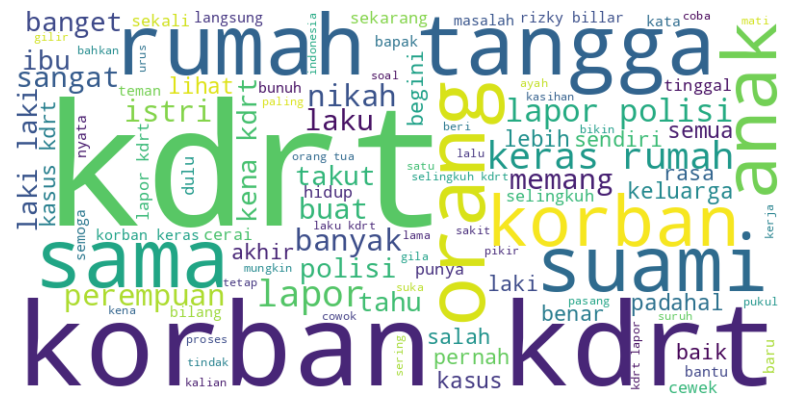

In [ ]:
from joblib.memory import textwrap
from os import putenv
custom_stopwords = set(STOPWORDS)
custom_stopwords.add("tidak")
custom_stopwords.add("jangan")
custom_stopwords.add("bukan")


wordcloud = WordCloud(width=800, height=400, background_color='white',
                         max_words=100,colormap='viridis',stopwords=custom_stopwords).generate(df_filtered2['final_preprocessed_text'].str.cat(sep=' '))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

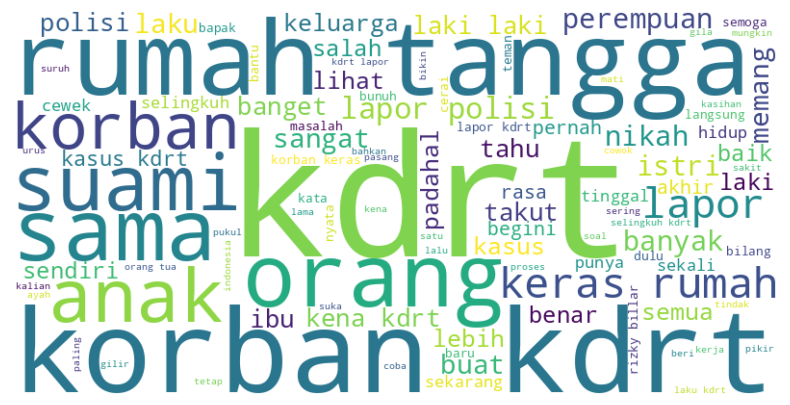

In [ ]:
from joblib.memory import textwrap
from os import putenv
custom_stopwords = set(STOPWORDS)
custom_stopwords.add("tidak")
custom_stopwords.add("jangan")
custom_stopwords.add("bukan")


wordcloud = WordCloud(width=800, height=400, background_color='white',
                         max_words=100,colormap='viridis',stopwords=custom_stopwords).generate(df2['final_preprocessed_text'].str.cat(sep=' '))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

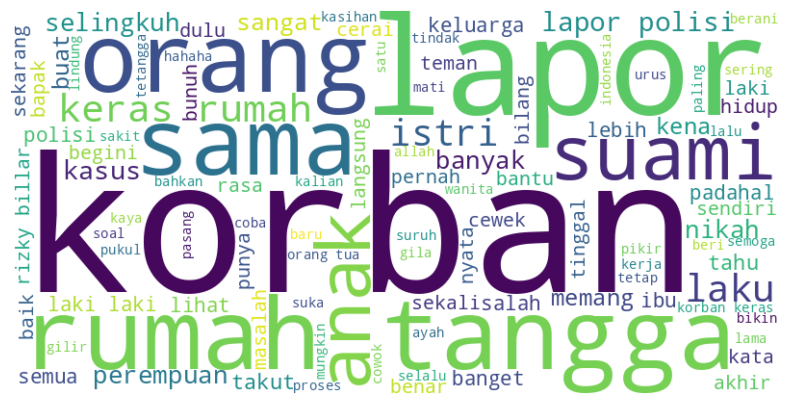

In [ ]:
from joblib.memory import textwrap
from os import putenv
custom_stopwords = set(STOPWORDS)
custom_stopwords.add("tidak")
custom_stopwords.add("jangan")
custom_stopwords.add("bukan")


wordcloud = WordCloud(width=800, height=400, background_color='white',
                         max_words=100,colormap='viridis',stopwords=custom_stopwords).generate(df_noKdrt_Final['final_preprocessed_text'].str.cat(sep=' '))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()